# Baseline-18D vs. Augmented EEG Observations for Future SNPE

**Scope.** 本 notebook 比较两套 *candidate* SNPE observation inputs，但不训练
posterior，也不评价哪套 posterior 更好。维数增加不自动意味着 inference 更好；
posterior 更窄也不等于 posterior 更准确。未来必须在相同 prior、simulator bank、
simulation budget、split、architecture、seed protocol、density estimator 和 PPC
protocol 下，用 synthetic recovery、expected coverage、local diagnostics 与
held-out predictive checks 判断增量价值：

\[
\text{incremental value}
= \text{better recovery/PPC} + \text{preserved calibration}.
\]

**Critical contract audit.** 任务名称沿用 requested `Baseline-18D`，但本地执行代码
是唯一裁判。若 `01_observation.ipynb` 实际没有 18 个 scalar summaries，本 notebook
不会用占位值、重命名或新版算法补齐维度；它会报告
`Reviewer note / Documentation-code mismatch`，并把该差异标为 SNPE blocker。

本 notebook 只做 schema、数值、support、missingness、redundancy、artifact reload
与 SNPE readiness 审计。单通道 Fpz-Cz scalp EEG observable 不等于 thalamic 或
cortical internal state，observable-level matching 不能证明内部机制正确。

## 1. Runtime, environment, paths, and immutable inputs

本节证明执行环境确为 `neurolib`，定位 repository root，并记录四个输入 notebook
的 SHA-256。只输出必要环境证据，不枚举无关环境变量。所有路径解析均从仓库结构
出发，不依赖个人绝对路径；原始 EDF 不会被复制到 artifacts。

In [1]:
from __future__ import annotations

from collections import Counter
from dataclasses import asdict
from datetime import datetime, timezone
from hashlib import sha256
from importlib import metadata
from pathlib import Path
import json
import os
import platform
import subprocess
import sys
import warnings

import matplotlib.pyplot as plt
import mne
import nbformat
import numpy as np
import pandas as pd
import scipy
import sbi

RANDOM_SEED = 20260723
RTOL = 1e-10
ATOL = 1e-12
np.random.seed(RANDOM_SEED)

def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / ".git").exists() and (candidate / "S4_sbi").exists():
            return candidate
    raise RuntimeError("Repository root containing .git and S4_sbi was not found")

REPO_ROOT = find_repo_root(Path.cwd().resolve())
SRC_ROOT = REPO_ROOT / "S4_sbi" / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

NOTEBOOK_DIR = REPO_ROOT / "S4_sbi" / "notebooks"
RESULT_DIR = REPO_ROOT / "S4_sbi" / "results" / "observation_schema_comparison"
FIGURE_DIR = RESULT_DIR / "figures"
RESULT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

SOURCE_NOTEBOOKS = [
    NOTEBOOK_DIR / "01_observation.ipynb",
    NOTEBOOK_DIR / "01_observation_annotated.ipynb",
    NOTEBOOK_DIR / "01_Pyloric_Inspired_Observation.ipynb",
    NOTEBOOK_DIR / "01_Pyloric_Inspired_Observation_annotated.ipynb",
]
for path in SOURCE_NOTEBOOKS:
    if not path.exists():
        raise FileNotFoundError(path)

def file_sha256(path: Path) -> str:
    return sha256(path.read_bytes()).hexdigest()

SOURCE_HASHES_AT_START = {path.name: file_sha256(path) for path in SOURCE_NOTEBOOKS}

CURRENT_NOTEBOOK_PATH = NOTEBOOK_DIR / "02_Observation_Schema_Comparison.ipynb"
current_notebook = nbformat.read(CURRENT_NOTEBOOK_PATH, as_version=4)
nbformat.validate(current_notebook)
nbformat_validation_result = "PASS"
kernel_id = current_notebook.metadata["kernelspec"]["name"]
kernel_display_name = current_notebook.metadata["kernelspec"]["display_name"]
git_status_short = subprocess.run(
    ["git", "status", "--short"],
    cwd=REPO_ROOT,
    check=True,
    capture_output=True,
    text=True,
    encoding="utf-8",
    errors="replace",
).stdout.rstrip()
git_diff_stat = subprocess.run(
    ["git", "diff", "--stat"],
    cwd=REPO_ROOT,
    check=True,
    capture_output=True,
    text=True,
    encoding="utf-8",
    errors="replace",
).stdout.rstrip()

env_name = os.environ.get("CONDA_DEFAULT_ENV")
env_evidence = pd.DataFrame(
    {
        "item": [
            "working_directory",
            "repository_root",
            "result_directory",
            "execution_time_utc",
            "conda_environment",
            "sys.executable",
            "sys.prefix",
            "Python",
            "NumPy",
            "SciPy",
            "pandas",
            "matplotlib",
            "MNE",
            "sbi",
            "nbformat",
            "random_seed",
        ],
        "value": [
            str(Path.cwd()),
            str(REPO_ROOT),
            str(RESULT_DIR.relative_to(REPO_ROOT)),
            datetime.now(timezone.utc).isoformat(),
            env_name,
            sys.executable,
            sys.prefix,
            platform.python_version(),
            np.__version__,
            scipy.__version__,
            pd.__version__,
            metadata.version("matplotlib"),
            mne.__version__,
            sbi.__version__,
            nbformat.__version__,
            RANDOM_SEED,
        ],
    }
)
with pd.option_context("display.max_colwidth", None, "display.width", 240):
    display(env_evidence)
    display(pd.DataFrame({"source_notebook": list(SOURCE_HASHES_AT_START), "sha256": list(SOURCE_HASHES_AT_START.values())}))
print(f"nbformat.validate(): {nbformat_validation_result}")
print(f"active conda environment: {env_name}")
print(f"sys.executable: {sys.executable}")
print(f"sys.prefix: {sys.prefix}")
print(f"kernel ID: {kernel_id}")
print(f"kernel display name: {kernel_display_name}")
print("Original notebook SHA-256:")
for source_name, source_hash in SOURCE_HASHES_AT_START.items():
    print(f"  {source_name}: {source_hash}")
print("\ngit status --short:")
print(git_status_short or "(clean)")
print("\ngit diff --stat:")
print(git_diff_stat or "(no tracked diff)")

assert env_name == "neurolib", f"Expected neurolib, got {env_name!r}"
assert "neurolib" in str(Path(sys.executable)).lower()
assert "neurolib" in str(Path(sys.prefix)).lower()

,item,value
0,working_directory,D:\Year3_Mao_Projects\sleep_loop\S4_sbi\notebooks
1,repository_root,D:\Year3_Mao_Projects\sleep_loop
2,result_directory,S4_sbi\results\observation_schema_comparison
3,execution_time_utc,2026-07-26T18:05:36.761476+00:00
4,conda_environment,neurolib
5,sys.executable,C:\Users\YUS190\AppData\Local\anaconda3\envs\neurolib\python.exe
6,sys.prefix,C:\Users\YUS190\AppData\Local\anaconda3\envs\neurolib
7,Python,3.10.20
8,NumPy,2.2.6
9,SciPy,1.15.2


,source_notebook,sha256
0,01_observation.ipynb,10045788079b7c65b55820054c0e7937f5f9adb8b736fb90ebb056a38101d755
1,01_observation_annotated.ipynb,91c349078bc1ed5c0f53f4b906b9dbf02e8c28422e010d7c568f79bbd27694eb
2,01_Pyloric_Inspired_Observation.ipynb,b954eb278536b8042da2a4651724e66387377cbd89fd22f70245aa8bd1db8c3c
3,01_Pyloric_Inspired_Observation_annotated.ipynb,7e1ad5b64ce2b93fba765939a5eca86d665ab0776ceb886a23bf0b7105dd6a8f


nbformat.validate(): PASS
active conda environment: neurolib
sys.executable: C:\Users\YUS190\AppData\Local\anaconda3\envs\neurolib\python.exe
sys.prefix: C:\Users\YUS190\AppData\Local\anaconda3\envs\neurolib
kernel ID: python3
kernel display name: neurolib
Original notebook SHA-256:
  01_observation.ipynb: 10045788079b7c65b55820054c0e7937f5f9adb8b736fb90ebb056a38101d755
  01_observation_annotated.ipynb: 91c349078bc1ed5c0f53f4b906b9dbf02e8c28422e010d7c568f79bbd27694eb
  01_Pyloric_Inspired_Observation.ipynb: b954eb278536b8042da2a4651724e66387377cbd89fd22f70245aa8bd1db8c3c
  01_Pyloric_Inspired_Observation_annotated.ipynb: 7e1ad5b64ce2b93fba765939a5eca86d665ab0776ceb886a23bf0b7105dd6a8f

git status --short:
 D S4_sbi/compute_xobs_from_eeg.py
 D S4_sbi/compute_xobs_from_eeg_v1_buggy.py
 D S4_sbi/compute_xobs_from_eeg_v2.py
 M S4_sbi/compute_xobs_from_eeg_v4.py
 M S4_sbi/notebooks/01_Pyloric_Inspired_Observation_annotated.ipynb
 D S4_sbi/plot_scan_diagnostics.py
 D S4_sbi/run_sbc_standalon

## 2. One recording, one global QC path, two feature libraries

两套方案共享同一个 SC4001 recording、Fpz-Cz channel、100 Hz sampling、
30 s epoch alignment、N3 selection 和 global QC。`build_observation_bundle`
是原 `01_observation.ipynb` 的实际入口；Pyloric-inspired extractor 只在同一个
retained-epoch population 上增加 observable-level temporal features。

这里严格区分：

- **global QC rejection**：N3 epoch 因 peak-to-peak 或 degenerate signal 被排除；
- **metric-specific invalid**：epoch 通过 global QC，但某指标 support 不足；
- **no detected event**：detector 有效且计数为 0；
- **insufficient event support**：计数不足，duration/phase 等量数学上未定义；
- **physiological zero**：只有算法定义允许且 detector 有效时才能使用 0；
- **processing failure**：filter/detector 失败，不能解释为生理 0。

In [2]:
from sleep_sbi.observation import (
    build_observation_bundle,
    load_observation_config,
)
from sleep_sbi.pyloric_inspired_observation import (
    CORE_FIELDS,
    build_pyloric_inspired_observation,
    load_pyloric_inspired_config,
)

OBS_CONFIG_PATH = REPO_ROOT / "S4_sbi" / "configs" / "observation_sc4001.yaml"
LATEST_CONFIG_PATH = (
    REPO_ROOT / "S4_sbi" / "configs" / "pyloric_inspired_observation_sc4001.yaml"
)
observation_config = load_observation_config(OBS_CONFIG_PATH)
latest_config = load_pyloric_inspired_config(LATEST_CONFIG_PATH)

bundle = build_observation_bundle(observation_config)
latest = build_pyloric_inspired_observation(
    bundle, observation_config, latest_config
)

total_epochs = int(bundle.provenance["recording_complete_epochs"])
n3_count = len(bundle.n3_epoch_indices)
retained_count = len(bundle.retained_epoch_indices)
rejected_count = len(bundle.rejected_epoch_indices)
accounting = pd.DataFrame(
    {
        "quantity": [
            "recording_complete_epochs",
            "all_N3_epochs",
            "retained_N3_epochs",
            "rejected_N3_epochs",
        ],
        "count": [total_epochs, n3_count, retained_count, rejected_count],
    }
)
display(accounting)
display(pd.Series(bundle.provenance["rejection_reason_counts"], name="count").to_frame())

assert retained_count + rejected_count == n3_count
assert set(bundle.retained_epoch_indices).isdisjoint(bundle.rejected_epoch_indices)
assert bundle.segments.shape == (
    retained_count,
    int(round(bundle.fs_hz * bundle.epoch_duration_s)),
)
assert (latest.epoch_ledger.loc[~latest.epoch_ledger["is_n3"], "global_qc_status"] == "not_applicable_non_n3").all()

source_data = pd.DataFrame(
    {
        "item": [
            "manifest",
            "PSG source identifier",
            "annotation source identifier",
            "subject",
            "channel",
            "sampling_rate_hz",
            "epoch_duration_s",
            "reference",
            "analysis_unit",
            "recording_duration_s",
            "observation_config_sha256",
            "latest_config_sha256",
        ],
        "value": [
            str(OBS_CONFIG_PATH.relative_to(REPO_ROOT)),
            bundle.provenance["psg_file"],
            bundle.provenance["hypnogram_file"],
            bundle.subject_id,
            bundle.channel,
            bundle.fs_hz,
            bundle.epoch_duration_s,
            bundle.provenance["reference"],
            bundle.provenance["analysis_unit"],
            bundle.provenance["recording_duration_s"],
            bundle.provenance["config_sha256"],
            sha256(LATEST_CONFIG_PATH.read_bytes()).hexdigest(),
        ],
    }
)
display(source_data)

D:\Year3_Mao_Projects\sleep_loop\S4_sbi\src\sleep_sbi\observation.py:117: DeprecationWarning: 
The `fooof` package is being deprecated and replaced by the `specparam` (spectral parameterization) package.
This version of `fooof` (1.1) is fully functional, but will not be further updated.
New projects are recommended to update to using `specparam` (see Changelog for details).
  from fooof import FOOOF


,quantity,count
0,recording_complete_epochs,2650
1,all_N3_epochs,220
2,retained_N3_epochs,142
3,rejected_N3_epochs,78


,count
peak_to_peak_above_threshold,78


,item,value
0,manifest,S4_sbi\configs\observation_sc4001.yaml
1,PSG source identifier,SC4001E0-PSG.edf
2,annotation source identifier,SC4001EC-Hypnogram.edf
3,subject,SC4001
4,channel,EEG Fpz-Cz
5,sampling_rate_hz,100.0
6,epoch_duration_s,30.0
7,reference,bipolar derivation Fpz-Cz as recorded; no addi...
8,analysis_unit,uV
9,recording_duration_s,79500.0


## 3. Executable contract audit: requested Baseline-18D versus actual Baseline

本节不根据 Markdown 名称推断维度，而是读取 `bundle.summaries` 的插入顺序。
当前 `01_observation.ipynb` 的 code cell 调用
`build_observation_bundle(config)`；因此其 scalar schema 就是该 mapping。

**Reviewer note / Documentation-code mismatch：**若实际维数不是 18，
`Baseline-18D` 不能被声称已复现。下面保留任务要求的名称用于 artifact 文件名，
但 schema metadata、图表和 readiness 结论始终报告实际维数。这个 blocker 必须在
pilot SNPE 前由研究者冻结，而不能在本 notebook 中擅自补齐。

In [3]:
baseline_feature_names = list(bundle.summaries.keys())
latest_feature_names = list(CORE_FIELDS)
REQUESTED_BASELINE_DIMENSION = 18
actual_baseline_dimension = len(baseline_feature_names)
requested_baseline18_available = (
    actual_baseline_dimension == REQUESTED_BASELINE_DIMENSION
)

contract_audit = pd.DataFrame(
    {
        "contract": [
            "Requested Baseline-18D",
            "Executable 01_observation scalar schema",
            "Pyloric-inspired latest EEG library",
        ],
        "dimension": [
            REQUESTED_BASELINE_DIMENSION,
            actual_baseline_dimension,
            len(latest_feature_names),
        ],
        "evidence": [
            "task specification",
            "ObservationBundle.summaries insertion order",
            "pyloric_inspired_observation.CORE_FIELDS",
        ],
        "status": [
            "unavailable" if not requested_baseline18_available else "available",
            "observed",
            "observed",
        ],
    }
)
display(contract_audit)
print("Actual baseline order:")
for index, name in enumerate(baseline_feature_names):
    print(f"{index:02d}: {name}")

assert actual_baseline_dimension == 14, (
    "The repository contract changed; re-audit before using this notebook."
)
assert len(latest_feature_names) == 18
assert len(set(baseline_feature_names)) == actual_baseline_dimension
assert len(set(latest_feature_names)) == len(latest_feature_names)

,contract,dimension,evidence,status
0,Requested Baseline-18D,18,task specification,unavailable
1,Executable 01_observation scalar schema,14,ObservationBundle.summaries insertion order,observed
2,Pyloric-inspired latest EEG library,18,pyloric_inspired_observation.CORE_FIELDS,observed


Actual baseline order:
00: fooof_aperiodic_exponent
01: so_peak_frequency_hz
02: relative_so_power
03: so_q
04: so_event_rate_per_min
05: ibi_cv
06: pac_up_down_ratio
07: spindle_density_per_min
08: spindle_mean_duration_s
09: pac_mi
10: pac_preferred_phase_rad
11: pac_preferred_phase_sin
12: pac_preferred_phase_cos
13: waveform_peak_to_peak_z


## 4. Feature crosswalk based on implementations, not names

`Exact match` 表示 record-level value、detector 和 aggregation 均复用原实现。
`Related but implementation changed` 表示名称或生理主题相似，但 continuous PAC
phase 与 event-conditioned spindle-onset phase 不是同一个统计量。后者属于真正新
observable dimension，不能覆盖 baseline continuous PAC coordinate。

Crosswalk 的 `Evidence/source` 指向实际 function/config/notebook cell。高相关或
确定性派生只产生 warning，不自动删除维度；是否保留必须在未来 ablation 中冻结。

In [4]:
exact_shared = [
    "fooof_aperiodic_exponent",
    "relative_so_power",
    "so_peak_frequency_hz",
    "so_q",
    "so_event_rate_per_min",
    "ibi_cv",
    "waveform_peak_to_peak_z",
    "spindle_density_per_min",
    "spindle_mean_duration_s",
]
phase_changed = {
    "pac_preferred_phase_cos": "spindle_onset_phase_cos",
    "pac_preferred_phase_sin": "spindle_onset_phase_sin",
}
baseline_only = [
    "pac_up_down_ratio",
    "pac_mi",
    "pac_preferred_phase_rad",
]
unmatched_new = [
    "so_median_ibi_s",
    "so_up_proxy_duration_s",
    "so_down_proxy_duration_s",
    "so_up_proxy_duty_cycle",
    "so_trough_to_peak_time_s",
    "spindle_occupancy",
    "spindle_onset_phase_concentration",
]
genuinely_new_feature_names = [
    "so_median_ibi_s",
    "so_up_proxy_duration_s",
    "so_down_proxy_duration_s",
    "so_up_proxy_duty_cycle",
    "so_trough_to_peak_time_s",
    "spindle_occupancy",
    "spindle_onset_phase_cos",
    "spindle_onset_phase_sin",
    "spindle_onset_phase_concentration",
]

baseline_units = {name: metric.unit for name, metric in bundle.summaries.items()}
latest_dictionary = latest.feature_dictionary.set_index("field_name")
rows = []
for name in exact_shared:
    rows.append(
        {
            "Baseline field": name,
            "Latest field": name,
            "Relationship": "Exact match",
            "Definition changed?": "No",
            "Change type": "",
            "Unit": baseline_units[name],
            "Baseline role": bundle.summaries[name].category,
            "Augmented role": "Baseline preserved",
            "Decision": "Preserve baseline prefix; do not append duplicate",
            "Evidence/source": "observation.py::build_observation_bundle; pyloric_inspired_observation.py::build_old_vs_new_regression; 01_observation.ipynb code cell 4",
        }
    )
for old_name, new_name in phase_changed.items():
    rows.append(
        {
            "Baseline field": old_name,
            "Latest field": new_name,
            "Relationship": "Related but implementation changed",
            "Definition changed?": "Yes",
            "Change type": "event support; aggregation; feature formula",
            "Unit": "1",
            "Baseline role": bundle.summaries[old_name].category,
            "Augmented role": "Candidate new dimension - requires freezing before SNPE",
            "Decision": "Preserve continuous-PAC baseline coordinate and append event-conditioned coordinate",
            "Evidence/source": "observation.py::_compute_pac_diagnostics versus pyloric_inspired_observation.py::pair_spindle_onsets_to_so_cycles",
        }
    )
for name in baseline_only:
    rows.append(
        {
            "Baseline field": name,
            "Latest field": "",
            "Relationship": "Baseline-only",
            "Definition changed?": "No",
            "Change type": "",
            "Unit": baseline_units[name],
            "Baseline role": bundle.summaries[name].category,
            "Augmented role": "Baseline preserved",
            "Decision": "Keep in prefix; not duplicated by latest core",
            "Evidence/source": "observation.py::build_observation_bundle; latest.auxiliary_diagnostics retains continuous PAC outside CORE_FIELDS",
        }
    )
for name in unmatched_new:
    relationship = (
        "Deterministic/near-deterministic derivative"
        if name in {"so_up_proxy_duty_cycle", "spindle_occupancy"}
        else "New dimension"
    )
    rows.append(
        {
            "Baseline field": "",
            "Latest field": name,
            "Relationship": relationship,
            "Definition changed?": "No",
            "Change type": "",
            "Unit": latest_dictionary.loc[name, "unit"],
            "Baseline role": "",
            "Augmented role": latest_dictionary.loc[name, "intended_role"],
            "Decision": "Append as candidate new dimension; preserve redundancy warning",
            "Evidence/source": "pyloric_inspired_observation.py::FEATURE_DEFINITIONS and build_core_summary; 01_Pyloric_Inspired_Observation.ipynb core-library cell",
        }
    )

crosswalk = pd.DataFrame(rows)
relationship_counts = crosswalk["Relationship"].value_counts()
final_augmented_feature_names = baseline_feature_names + genuinely_new_feature_names
crosswalk_overview = pd.DataFrame(
    {
        "quantity": [
            "requested baseline dimension",
            "actual executable baseline dimension",
            "latest library dimension",
            "exact shared",
            "renamed exact match",
            "implementation changed and appended",
            "unmatched genuinely new",
            "all genuinely new appended",
            "baseline-only",
            "unresolved",
            "final augmented dimension",
        ],
        "count": [
            REQUESTED_BASELINE_DIMENSION,
            actual_baseline_dimension,
            len(latest_feature_names),
            len(exact_shared),
            0,
            len(phase_changed),
            len(unmatched_new),
            len(genuinely_new_feature_names),
            len(baseline_only),
            0,
            len(final_augmented_feature_names),
        ],
    }
)
display(crosswalk)
display(crosswalk_overview)

assert final_augmented_feature_names[:actual_baseline_dimension] == baseline_feature_names
assert len(final_augmented_feature_names) == 23

,Baseline field,Latest field,Relationship,Definition changed?,Change type,Unit,Baseline role,Augmented role,Decision,Evidence/source
0,fooof_aperiodic_exponent,fooof_aperiodic_exponent,Exact match,No,,1,inference_summary_candidate,Baseline preserved,Preserve baseline prefix; do not append duplicate,observation.py::build_observation_bundle; pylo...
1,relative_so_power,relative_so_power,Exact match,No,,1,inference_summary_candidate,Baseline preserved,Preserve baseline prefix; do not append duplicate,observation.py::build_observation_bundle; pylo...
2,so_peak_frequency_hz,so_peak_frequency_hz,Exact match,No,,Hz,inference_summary_candidate,Baseline preserved,Preserve baseline prefix; do not append duplicate,observation.py::build_observation_bundle; pylo...
3,so_q,so_q,Exact match,No,,1,inference_summary_candidate,Baseline preserved,Preserve baseline prefix; do not append duplicate,observation.py::build_observation_bundle; pylo...
4,so_event_rate_per_min,so_event_rate_per_min,Exact match,No,,events/min,inference_summary_candidate,Baseline preserved,Preserve baseline prefix; do not append duplicate,observation.py::build_observation_bundle; pylo...
5,ibi_cv,ibi_cv,Exact match,No,,1,inference_summary_candidate,Baseline preserved,Preserve baseline prefix; do not append duplicate,observation.py::build_observation_bundle; pylo...
6,waveform_peak_to_peak_z,waveform_peak_to_peak_z,Exact match,No,,z,held_out_ppc_candidate,Baseline preserved,Preserve baseline prefix; do not append duplicate,observation.py::build_observation_bundle; pylo...
7,spindle_density_per_min,spindle_density_per_min,Exact match,No,,events/min,held_out_ppc_candidate,Baseline preserved,Preserve baseline prefix; do not append duplicate,observation.py::build_observation_bundle; pylo...
8,spindle_mean_duration_s,spindle_mean_duration_s,Exact match,No,,s,held_out_ppc_candidate,Baseline preserved,Preserve baseline prefix; do not append duplicate,observation.py::build_observation_bundle; pylo...
9,pac_preferred_phase_cos,spindle_onset_phase_cos,Related but implementation changed,Yes,event support; aggregation; feature formula,1,held_out_ppc_candidate,Candidate new dimension - requires freezing be...,Preserve continuous-PAC baseline coordinate an...,observation.py::_compute_pac_diagnostics versu...


,quantity,count
0,requested baseline dimension,18
1,actual executable baseline dimension,14
2,latest library dimension,18
3,exact shared,9
4,renamed exact match,0
5,implementation changed and appended,2
6,unmatched genuinely new,7
7,all genuinely new appended,9
8,baseline-only,3
9,unresolved,0


## 5. Formal Scheme A and Scheme B schema tables

Scheme A 表示原 extractor **实际可执行的 14D scalar contract**，而不是伪造的
18D。Scheme B 严格构造为

\[
x_{aug}=[x_{baseline}, x_{genuinely\ new}],
\]

因此前 14 项逐项标记 `Baseline preserved`，新增 9 项追加在末尾。当前所有
`freeze status` 均为 candidate/provisional：尚未证明 simulation 能使用完全相同
observable extractor，也尚未冻结 scaling、missingness policy 和 held-out design。

In [5]:
GROUPS = {
    "fooof_aperiodic_exponent": "spectrum",
    "relative_so_power": "spectrum",
    "so_peak_frequency_hz": "spectrum",
    "so_q": "spectrum",
    "so_event_rate_per_min": "SO rhythm",
    "so_median_ibi_s": "SO rhythm",
    "ibi_cv": "SO rhythm",
    "so_up_proxy_duration_s": "SO morphology",
    "so_down_proxy_duration_s": "SO morphology",
    "so_up_proxy_duty_cycle": "SO morphology",
    "waveform_peak_to_peak_z": "SO morphology",
    "so_trough_to_peak_time_s": "SO morphology",
    "spindle_density_per_min": "spindle",
    "spindle_mean_duration_s": "spindle",
    "spindle_occupancy": "spindle",
    "pac_up_down_ratio": "continuous PAC",
    "pac_mi": "continuous PAC",
    "pac_preferred_phase_rad": "continuous PAC",
    "pac_preferred_phase_sin": "continuous PAC",
    "pac_preferred_phase_cos": "continuous PAC",
    "spindle_onset_phase_cos": "SO-spindle coordination",
    "spindle_onset_phase_sin": "SO-spindle coordination",
    "spindle_onset_phase_concentration": "SO-spindle coordination",
}
SCALING = {
    "events/min": "consider log1p then training-set standardization",
    "s": "consider log then training-set standardization",
    "Hz": "training-set standardization",
    "rad": "do not linearly scale raw angle; prefer circular coordinates",
    "z": "training-set standardization",
    "1": "training-set standardization; inspect bounds/skew first",
}

baseline_schema_rows = []
for index, (name, metric) in enumerate(bundle.summaries.items()):
    payload = asdict(metric)
    baseline_schema_rows.append(
        {
            "index": index,
            "feature_name": name,
            "feature_group": GROUPS[name],
            "definition": metric.algorithm,
            "unit": metric.unit,
            "preprocessing/filter": json.dumps(payload["parameters"], sort_keys=True),
            "aggregation": metric.aggregation,
            "valid_support_rule": f"valid={metric.valid}; valid_epoch_count={metric.valid_epoch_count}",
            "missing_value_meaning": metric.invalid_reason or "NaN means undefined/processing failure, never silently zero-filled",
            "transform/scaling_requirement": SCALING[metric.unit],
            "source_function": "sleep_sbi.observation.build_observation_bundle",
            "source_notebook": "S4_sbi/notebooks/01_observation.ipynb",
            "recommended_inference_role": metric.category,
            "freeze_status": "existing observation definition; SNPE contract not frozen",
        }
    )
scheme_a_schema = pd.DataFrame(baseline_schema_rows)

new_summary = latest.summary.set_index("field_name")
augmented_rows = []
for index, name in enumerate(final_augmented_feature_names):
    if index < actual_baseline_dimension:
        source = scheme_a_schema.set_index("feature_name").loc[name]
        augmented_rows.append(
            {
                "augmented_index": index,
                "feature_name": name,
                "baseline_or_new": "Baseline preserved",
                "feature_group": source["feature_group"],
                "definition": source["definition"],
                "unit": source["unit"],
                "preprocessing/filter": source["preprocessing/filter"],
                "aggregation": source["aggregation"],
                "valid_support_rule": source["valid_support_rule"],
                "missing_value_meaning": source["missing_value_meaning"],
                "transform/scaling_requirement": source["transform/scaling_requirement"],
                "redundancy_warning": "",
                "source_implementation": source["source_function"],
                "recommended_inference_role": source["recommended_inference_role"],
                "freeze_status": "Baseline preserved; full Baseline-18D claim unresolved",
            }
        )
    else:
        definition = latest_dictionary.loc[name]
        summary_row = new_summary.loc[name]
        augmented_rows.append(
            {
                "augmented_index": index,
                "feature_name": name,
                "baseline_or_new": "Genuinely new",
                "feature_group": GROUPS[name],
                "definition": definition["algorithm"],
                "unit": definition["unit"],
                "preprocessing/filter": definition["frequency_band"],
                "aggregation": definition["aggregation_method"],
                "valid_support_rule": f"validity={summary_row['validity_status']}; valid_epoch_count={summary_row['valid_epoch_count']}",
                "missing_value_meaning": "NaN is metric-specific undefined or insufficient support; inspect reason column",
                "transform/scaling_requirement": SCALING[definition["unit"]],
                "redundancy_warning": definition["dependency_or_redundancy"],
                "source_implementation": "sleep_sbi.pyloric_inspired_observation",
                "recommended_inference_role": definition["intended_role"],
                "freeze_status": "Candidate new dimension - requires freezing before SNPE",
            }
        )
scheme_b_schema = pd.DataFrame(augmented_rows)

display(scheme_a_schema)
display(scheme_b_schema)
assert scheme_b_schema.iloc[:actual_baseline_dimension]["feature_name"].tolist() == baseline_feature_names

,index,feature_name,feature_group,definition,unit,preprocessing/filter,aggregation,valid_support_rule,missing_value_meaning,transform/scaling_requirement,source_function,source_notebook,recommended_inference_role,freeze_status
0,0,fooof_aperiodic_exponent,spectrum,FOOOF fixed aperiodic fit,1,"{""aperiodic_mode"": ""fixed"", ""fooof_version"": ""...",fit to arithmetic-mean Hann epoch PSD,valid=True; valid_epoch_count=142,"NaN means undefined/processing failure, never ...",training-set standardization; inspect bounds/s...,sleep_sbi.observation.build_observation_bundle,S4_sbi/notebooks/01_observation.ipynb,inference_summary_candidate,existing observation definition; SNPE contract...
1,1,so_peak_frequency_hz,spectrum,maximum of aggregate Welch PSD in SO band,Hz,"{""algorithm"": ""scipy.signal.welch"", ""detrend"":...",arithmetic mean across retained epoch PSDs,valid=True; valid_epoch_count=142,"NaN means undefined/processing failure, never ...",training-set standardization,sleep_sbi.observation.build_observation_bundle,S4_sbi/notebooks/01_observation.ipynb,inference_summary_candidate,existing observation definition; SNPE contract...
2,2,relative_so_power,spectrum,SO-band trapezoidal power / analysis-band power,1,"{""denominator_band_hz"": [0.5, 20.0]}",ratio from aggregate Hann PSD,valid=True; valid_epoch_count=142,"NaN means undefined/processing failure, never ...",training-set standardization; inspect bounds/s...,sleep_sbi.observation.build_observation_bundle,S4_sbi/notebooks/01_observation.ipynb,inference_summary_candidate,existing observation definition; SNPE contract...
3,3,so_q,spectrum,SO peak PSD / mean adjacent-band PSD,1,{},computed from aggregate Hann PSD,valid=True; valid_epoch_count=142,"NaN means undefined/processing failure, never ...",training-set standardization; inspect bounds/s...,sleep_sbi.observation.build_observation_bundle,S4_sbi/notebooks/01_observation.ipynb,inference_summary_candidate,existing observation definition; SNPE contract...
4,4,so_event_rate_per_min,SO rhythm,AASM-style DOWN-to-UP half-wave detector,events/min,"{""band_hz"": [0.2, 4.0], ""down_to_up_duration_s...",events summed across epochs / retained N3 minutes,valid=True; valid_epoch_count=142,"NaN means undefined/processing failure, never ...",consider log1p then training-set standardization,sleep_sbi.observation.build_observation_bundle,S4_sbi/notebooks/01_observation.ipynb,inference_summary_candidate,existing observation definition; SNPE contract...
5,5,ibi_cv,SO rhythm,coefficient of variation of within-epoch SO UP...,1,"{""band_hz"": [0.2, 4.0], ""down_to_up_duration_s...",all within-epoch intervals pooled; no boundary...,valid=True; valid_epoch_count=124,"NaN means undefined/processing failure, never ...",training-set standardization; inspect bounds/s...,sleep_sbi.observation.build_observation_bundle,S4_sbi/notebooks/01_observation.ipynb,inference_summary_candidate,existing observation definition; SNPE contract...
6,6,pac_up_down_ratio,continuous PAC,spindle-envelope amplitude at UP phases / DOWN...,1,"{""aggregation"": ""phase-bin amplitude sums acro...",sample amplitudes pooled after per-epoch filte...,valid=True; valid_epoch_count=142,"NaN means undefined/processing failure, never ...",training-set standardization; inspect bounds/s...,sleep_sbi.observation.build_observation_bundle,S4_sbi/notebooks/01_observation.ipynb,mechanism_diagnostic,existing observation definition; SNPE contract...
7,7,spindle_density_per_min,spindle,sigma-band moving-RMS detector,events/min,"{""band_hz"": [11.0, 15.0], ""duration_s"": [0.5, ...",events summed across epochs / retained N3 minutes,valid=True; valid_epoch_count=142,"NaN means undefined/processing failure, never ...",consider log1p then training-set standardization,sleep_sbi.observation.build_observation_bundle,S4_sbi/notebooks/01_observation.ipynb,held_out_ppc_candidate,existing observation definition; SNPE contract...
8,8,spindle_mean_duration_s,spindle,sigma-band moving-RMS detector,s,"{""band_h

,augmented_index,feature_name,baseline_or_new,feature_group,definition,unit,preprocessing/filter,aggregation,valid_support_rule,missing_value_meaning,transform/scaling_requirement,redundancy_warning,source_implementation,recommended_inference_role,freeze_status
0,0,fooof_aperiodic_exponent,Baseline preserved,spectrum,FOOOF fixed aperiodic fit,1,"{""aperiodic_mode"": ""fixed"", ""fooof_version"": ""...",fit to arithmetic-mean Hann epoch PSD,valid=True; valid_epoch_count=142,"NaN means undefined/processing failure, never ...",training-set standardization; inspect bounds/s...,,sleep_sbi.observation.build_observation_bundle,inference_summary_candidate,Baseline preserved; full Baseline-18D claim un...
1,1,so_peak_frequency_hz,Baseline preserved,spectrum,maximum of aggregate Welch PSD in SO band,Hz,"{""algorithm"": ""scipy.signal.welch"", ""detrend"":...",arithmetic mean across retained epoch PSDs,valid=True; valid_epoch_count=142,"NaN means undefined/processing failure, never ...",training-set standardization,,sleep_sbi.observation.build_observation_bundle,inference_summary_candidate,Baseline preserved; full Baseline-18D claim un...
2,2,relative_so_power,Baseline preserved,spectrum,SO-band trapezoidal power / analysis-band power,1,"{""denominator_band_hz"": [0.5, 20.0]}",ratio from aggregate Hann PSD,valid=True; valid_epoch_count=142,"NaN means undefined/processing failure, never ...",training-set standardization; inspect bounds/s...,,sleep_sbi.observation.build_observation_bundle,inference_summary_candidate,Baseline preserved; full Baseline-18D claim un...
3,3,so_q,Baseline preserved,spectrum,SO peak PSD / mean adjacent-band PSD,1,{},computed from aggregate Hann PSD,valid=True; valid_epoch_count=142,"NaN means undefined/processing failure, never ...",training-set standardization; inspect bounds/s...,,sleep_sbi.observation.build_observation_bundle,inference_summary_candidate,Baseline preserved; full Baseline-18D claim un...
4,4,so_event_rate_per_min,Baseline preserved,SO rhythm,AASM-style DOWN-to-UP half-wave detector,events/min,"{""band_hz"": [0.2, 4.0], ""down_to_up_duration_s...",events summed across epochs / retained N3 minutes,valid=True; valid_epoch_count=142,"NaN means undefined/processing failure, never ...",consider log1p then training-set standardization,,sleep_sbi.observation.build_observation_bundle,inference_summary_candidate,Baseline preserved; full Baseline-18D claim un...
5,5,ibi_cv,Baseline preserved,SO rhythm,coefficient of variation of within-epoch SO UP...,1,"{""band_hz"": [0.2, 4.0], ""down_to_up_duration_s...",all within-epoch intervals pooled; no boundary...,valid=True; valid_epoch_count=124,"NaN means undefined/processing failure, never ...",training-set standardization; inspect bounds/s...,,sleep_sbi.observation.build_observation_bundle,inference_summary_candidate,Baseline preserved; full Baseline-18D claim un...
6,6,pac_up_down_ratio,Baseline preserved,continuous PAC,spindle-envelope amplitude at UP phases / DOWN...,1,"{""aggregation"": ""phase-bin amplitude sums acro...",sample amplitudes pooled after per-epoch filte...,valid=True; valid_epoch_count=142,"NaN means undefined/processing failure, never ...",training-set standardization; inspect bounds/s...,,sleep_sbi.observation.build_observation_bundle,mechanism_diagnostic,Baseline preserved; full Baseline-18D claim un...
7,7,spindle_density_per_min,Baseline preserved,spindle,sigma-band moving-RMS detector,events/min,"{""band_hz"": [11.0, 15.0], ""duration_s"": [0.5, ...",events summed across epochs / retained N3 minutes,valid=True; valid_epoch_count=142,"NaN means undefined/processing failure, never ...",consider log1p then training-set standardization,,sleep_sbi.observation.build_observation_bundle,held_out_ppc_candidate,Baseline preserved; full Baseline-18D claim un...
8,8,spindle_mean_duration_s,Baseline preserved,spindle,sigma-band moving-RMS detector,s,"{""band_hz"": [11.0, 15.0], ""duration_s"": [0.5, ...",arithmetic mean across detected events,valid

## 6. Per-epoch matrices and Constructive prefix identity

原 ObservationBundle 没有导出完整 per-epoch scalar matrix。这里的 wrapper 只做
编排：exact-shared fields 使用 latest extractor 对同一 retained epoch 的
per-epoch outputs；continuous PAC fields 直接来自原 bundle 的 `pac.per_epoch`。
它不改变 filter、threshold、aggregation 或 event definition。

**Constructive prefix identity.** `X_augmented` 是显式通过
`[X_baseline, X_new]` 构造的，因此 prefix equality 是 schema construction
与列顺序检查，**不是两个独立 extractors 之间的 regression validation**。
record-level shared values 另由 `old_vs_new_regression` 检查 9 个 exact-shared
aggregates 的数值一致性。

In [6]:
per_epoch_latest = latest.per_epoch_features.set_index("epoch_index")
pac_per_epoch = pd.DataFrame(bundle.diagnostics["pac"]["per_epoch"]).set_index("epoch_index")
retained_ids = np.asarray(bundle.retained_epoch_indices, dtype=int)
assert per_epoch_latest.index.to_numpy().tolist() == retained_ids.tolist()
assert pac_per_epoch.index.to_numpy().tolist() == retained_ids.tolist()

baseline_per_epoch = pd.DataFrame(index=retained_ids)
baseline_per_epoch.index.name = "epoch_index"
for name in baseline_feature_names:
    if name in per_epoch_latest.columns:
        baseline_per_epoch[name] = per_epoch_latest[name].astype(float)
    elif name == "pac_mi":
        baseline_per_epoch[name] = pac_per_epoch["mi"].astype(float)
    elif name == "pac_preferred_phase_rad":
        baseline_per_epoch[name] = pac_per_epoch["preferred_phase_rad"].astype(float)
    elif name == "pac_preferred_phase_sin":
        baseline_per_epoch[name] = pac_per_epoch["preferred_phase_sin"].astype(float)
    elif name == "pac_preferred_phase_cos":
        baseline_per_epoch[name] = pac_per_epoch["preferred_phase_cos"].astype(float)
    elif name == "pac_up_down_ratio":
        baseline_per_epoch[name] = pac_per_epoch["pac_up_down_ratio"].astype(float)
    else:
        raise KeyError(f"No audited per-epoch source for {name}")

new_per_epoch = per_epoch_latest[genuinely_new_feature_names].astype(float).copy()
augmented_per_epoch = pd.concat([baseline_per_epoch, new_per_epoch], axis=1)
X_baseline = baseline_per_epoch.to_numpy(dtype=np.float64)
X_augmented = augmented_per_epoch.to_numpy(dtype=np.float64)

per_epoch_equality_rows = []
for index, name in enumerate(baseline_feature_names):
    left = X_baseline[:, index]
    right = X_augmented[:, index]
    finite_pair = np.isfinite(left) & np.isfinite(right)
    max_abs_diff = (
        float(np.max(np.abs(left[finite_pair] - right[finite_pair])))
        if finite_pair.any()
        else np.nan
    )
    nan_match = np.array_equal(np.isnan(left), np.isnan(right))
    support_match = np.array_equal(np.isfinite(left), np.isfinite(right))
    passed = bool(
        nan_match
        and support_match
        and np.allclose(left, right, rtol=RTOL, atol=ATOL, equal_nan=True)
    )
    per_epoch_equality_rows.append(
        {
            "Feature": name,
            "Identity type": "Constructive prefix identity",
            "Max abs diff": max_abs_diff,
            "NaN mask match": nan_match,
            "Support match": support_match,
            "Aggregation diff": 0.0,
            "Pass": passed,
        }
    )
per_epoch_equality = pd.DataFrame(per_epoch_equality_rows)
display(pd.DataFrame({"matrix": ["X_baseline", "X_augmented"], "shape": [X_baseline.shape, X_augmented.shape]}))
display(per_epoch_equality)

assert X_baseline.shape == (retained_count, actual_baseline_dimension)
assert X_augmented.shape == (retained_count, len(final_augmented_feature_names))
assert np.array_equal(np.isnan(X_augmented[:, :actual_baseline_dimension]), np.isnan(X_baseline))
assert np.allclose(
    X_augmented[:, :actual_baseline_dimension],
    X_baseline,
    rtol=RTOL,
    atol=ATOL,
    equal_nan=True,
)
assert per_epoch_equality["Pass"].all()

,matrix,shape
0,X_baseline,"(142, 14)"
1,X_augmented,"(142, 23)"


,Feature,Identity type,Max abs diff,NaN mask match,Support match,Aggregation diff,Pass
0,fooof_aperiodic_exponent,Constructive prefix identity,0.0,True,True,0.0,True
1,so_peak_frequency_hz,Constructive prefix identity,0.0,True,True,0.0,True
2,relative_so_power,Constructive prefix identity,0.0,True,True,0.0,True
3,so_q,Constructive prefix identity,0.0,True,True,0.0,True
4,so_event_rate_per_min,Constructive prefix identity,0.0,True,True,0.0,True
5,ibi_cv,Constructive prefix identity,0.0,True,True,0.0,True
6,pac_up_down_ratio,Constructive prefix identity,0.0,True,True,0.0,True
7,spindle_density_per_min,Constructive prefix identity,0.0,True,True,0.0,True
8,spindle_mean_duration_s,Constructive prefix identity,0.0,True,True,0.0,True
9,pac_mi,Constructive prefix identity,0.0,True,True,0.0,True


## 7. Record-level vectors and aggregate equality

`x_o_baseline` 按原 `bundle.summaries` 顺序取值；新增部分按 latest core summary
的定义取值。没有自行使用 `mean`/`median` 替换原 aggregation。由于实际 baseline
contract 是 14D，本节不能诚实执行任务文本中的 `(18,)` assertion；相反，它将
requested shape 显式列为 blocker，并验证实际 fixed-length shapes、prefix、
NaN mask 与 floating-point equality。

In [7]:
x_o_baseline = np.asarray(
    [bundle.summaries[name].value for name in baseline_feature_names],
    dtype=np.float64,
)
x_o_new = np.asarray(
    [float(new_summary.loc[name, "value"]) for name in genuinely_new_feature_names],
    dtype=np.float64,
)
x_o_augmented = np.concatenate([x_o_baseline, x_o_new])

record_equality = pd.DataFrame(
    {
        "check": [
            "actual baseline fixed length",
            "requested Baseline-18D available",
            "augmented fixed length",
            "prefix NaN mask equality",
            "prefix numeric equality",
            "baseline Inf count",
            "augmented Inf count",
            "baseline NaN count",
            "augmented NaN count",
        ],
        "result": [
            x_o_baseline.shape == (actual_baseline_dimension,),
            x_o_baseline.shape == (REQUESTED_BASELINE_DIMENSION,),
            x_o_augmented.shape == (len(final_augmented_feature_names),),
            np.array_equal(np.isnan(x_o_augmented[:actual_baseline_dimension]), np.isnan(x_o_baseline)),
            np.allclose(
                x_o_augmented[:actual_baseline_dimension],
                x_o_baseline,
                rtol=RTOL,
                atol=ATOL,
                equal_nan=True,
            ),
            int(np.isinf(x_o_baseline).sum()),
            int(np.isinf(x_o_augmented).sum()),
            int(np.isnan(x_o_baseline).sum()),
            int(np.isnan(x_o_augmented).sum()),
        ],
    }
)
vector_table = pd.DataFrame(
    {
        "augmented_index": np.arange(len(final_augmented_feature_names)),
        "feature_name": final_augmented_feature_names,
        "value": x_o_augmented,
        "status": ["Baseline preserved"] * actual_baseline_dimension
        + ["Genuinely new"] * len(genuinely_new_feature_names),
    }
).merge(
    scheme_b_schema[["feature_name", "unit", "aggregation", "freeze_status"]],
    on="feature_name",
    how="left",
)
display(record_equality)
display(vector_table)

assert x_o_baseline.shape == (actual_baseline_dimension,)
assert x_o_augmented.shape == (len(final_augmented_feature_names),)
assert np.array_equal(
    np.isnan(x_o_augmented[:actual_baseline_dimension]),
    np.isnan(x_o_baseline),
)
assert np.allclose(
    x_o_augmented[:actual_baseline_dimension],
    x_o_baseline,
    rtol=RTOL,
    atol=ATOL,
    equal_nan=True,
)

regression_shared = latest.old_vs_new_regression.query(
    "old_field_name in @exact_shared"
).copy()
display(regression_shared)
assert regression_shared["status"].eq("pass").all()
assert (regression_shared["absolute_difference"] <= ATOL).all()

,check,result
0,actual baseline fixed length,True
1,requested Baseline-18D available,False
2,augmented fixed length,True
3,prefix NaN mask equality,True
4,prefix numeric equality,True
5,baseline Inf count,0
6,augmented Inf count,0
7,baseline NaN count,0
8,augmented NaN count,0


,augmented_index,feature_name,value,status,unit,aggregation,freeze_status
0,0,fooof_aperiodic_exponent,2.558807,Baseline preserved,1,fit to arithmetic-mean Hann epoch PSD,Baseline preserved; full Baseline-18D claim un...
1,1,so_peak_frequency_hz,0.500000,Baseline preserved,Hz,arithmetic mean across retained epoch PSDs,Baseline preserved; full Baseline-18D claim un...
2,2,relative_so_power,0.777428,Baseline preserved,1,ratio from aggregate Hann PSD,Baseline preserved; full Baseline-18D claim un...
3,3,so_q,4.869293,Baseline preserved,1,computed from aggregate Hann PSD,Baseline preserved; full Baseline-18D claim un...
4,4,so_event_rate_per_min,13.112676,Baseline preserved,events/min,events summed across epochs / retained N3 minutes,Baseline preserved; full Baseline-18D claim un...
5,5,ibi_cv,1.011715,Baseline preserved,1,all within-epoch intervals pooled; no boundary...,Baseline preserved; full Baseline-18D claim un...
6,6,pac_up_down_ratio,1.034337,Baseline preserved,1,sample amplitudes pooled after per-epoch filte...,Baseline preserved; full Baseline-18D claim un...
7,7,spindle_density_per_min,2.859155,Baseline preserved,events/min,events summed across epochs / retained N3 minutes,Baseline preserved; full Baseline-18D claim un...
8,8,spindle_mean_duration_s,0.676798,Baseline preserved,s,arithmetic mean across detected events,Baseline preserved; full Baseline-18D claim un...
9,9,pac_mi,0.000204,Baseline preserved,1,phase-bin amplitude pooled after per-epoch fil...,Baseline preserved; full Baseline-18D claim un...


,old_field_name,new_field_name,old_value,new_value,absolute_difference,relative_difference,tolerance,status,difference_reason
0,fooof_aperiodic_exponent,fooof_aperiodic_exponent,2.558807,2.558807,0.0,0.0,1.000000e-10,pass,exact upstream aggregate reuse
1,relative_so_power,relative_so_power,0.777428,0.777428,0.0,0.0,1.000000e-10,pass,exact upstream aggregate reuse
2,so_peak_frequency_hz,so_peak_frequency_hz,0.500000,0.500000,0.0,0.0,1.000000e-10,pass,exact upstream aggregate reuse
3,so_q,so_q,4.869293,4.869293,0.0,0.0,1.000000e-10,pass,exact upstream aggregate reuse
4,so_event_rate_per_min,so_event_rate_per_min,13.112676,13.112676,0.0,0.0,1.000000e-10,pass,exact upstream detector and aggregate reuse
5,ibi_cv,ibi_cv,1.011715,1.011715,0.0,0.0,1.000000e-10,pass,exact upstream pooled-within-epoch definition ...
6,waveform_peak_to_peak_z,waveform_peak_to_peak_z,1.993695,1.993695,0.0,0.0,1.000000e-10,pass,exact upstream aggregate waveform reuse
7,spindle_density_per_min,spindle_density_per_min,2.859155,2.859155,0.0,0.0,1.000000e-10,pass,exact upstream detector and aggregate reuse
8,spindle_mean_duration_s,spindle_mean_duration_s,0.676798,0.676798,0.0,0.0,1.000000e-10,pass,exact upstream event-duration aggregate reuse


## 8. Dimension overview, valid support, and missingness

每个 feature 的 support 按同一 142 个 retained epochs 计算。NaN 不会填 0。
对 event metrics，`valid event count` 与 `valid epoch count` 分开；0-event epoch
只有在 detector 有效时才允许 density/occupancy 为 0，而 duration 与 phase
仍应是 undefined。Circular coordinates 的 sin/cos/concentration 必须共享同一
pairing validity mask。

In [8]:
event_column = {
    "so_event_rate_per_min": "so_event_count",
    "so_median_ibi_s": "ibi_interval_count",
    "ibi_cv": "ibi_interval_count",
    "so_up_proxy_duration_s": "so_proxy_cycle_count",
    "so_down_proxy_duration_s": "so_proxy_cycle_count",
    "so_up_proxy_duty_cycle": "so_proxy_cycle_count",
    "so_trough_to_peak_time_s": "so_proxy_cycle_count",
    "waveform_peak_to_peak_z": "waveform_event_count",
    "spindle_density_per_min": "spindle_event_count",
    "spindle_mean_duration_s": "spindle_event_count",
    "spindle_occupancy": "spindle_event_count",
    "spindle_onset_phase_cos": "paired_event_count",
    "spindle_onset_phase_sin": "paired_event_count",
    "spindle_onset_phase_concentration": "paired_event_count",
}
reason_column = {
    "ibi_cv": "ibi_invalid_reason",
    "so_median_ibi_s": "ibi_invalid_reason",
    "so_up_proxy_duration_s": "so_proxy_invalid_reason",
    "so_down_proxy_duration_s": "so_proxy_invalid_reason",
    "so_up_proxy_duty_cycle": "so_proxy_invalid_reason",
    "so_trough_to_peak_time_s": "so_proxy_invalid_reason",
    "waveform_peak_to_peak_z": "waveform_invalid_reason",
    "spindle_density_per_min": "spindle_invalid_reason",
    "spindle_mean_duration_s": "spindle_invalid_reason",
    "spindle_occupancy": "spindle_invalid_reason",
    "spindle_onset_phase_cos": "pairing_invalid_reason",
    "spindle_onset_phase_sin": "pairing_invalid_reason",
    "spindle_onset_phase_concentration": "pairing_invalid_reason",
}
minimum_support = {
    "ibi_cv": ">=2 within-epoch intervals (>=3 SO events)",
    "so_median_ibi_s": ">=2 within-epoch intervals",
    "spindle_mean_duration_s": ">=1 detected spindle",
    "spindle_onset_phase_cos": f">={latest_config.minimum_per_epoch_paired_events} paired onsets/epoch",
    "spindle_onset_phase_sin": f">={latest_config.minimum_per_epoch_paired_events} paired onsets/epoch",
    "spindle_onset_phase_concentration": f">={latest_config.minimum_per_epoch_paired_events} paired onsets/epoch",
}
zero_semantics = {
    "so_event_rate_per_min": "0 = no detected event in a detector-valid epoch; not proof of physiological absence",
    "spindle_density_per_min": "0 = no detected spindle in a detector-valid epoch",
    "spindle_occupancy": "0 = zero union duration in a detector-valid epoch",
}

support_rows = []
for name in final_augmented_feature_names:
    values = augmented_per_epoch[name].to_numpy(float)
    valid_mask = np.isfinite(values)
    event_name = event_column.get(name)
    events = (
        per_epoch_latest[event_name].to_numpy(float)
        if event_name is not None
        else np.full(retained_count, np.nan)
    )
    reason_name = reason_column.get(name)
    reasons = (
        per_epoch_latest.loc[~valid_mask, reason_name].dropna().astype(str)
        if reason_name is not None
        else pd.Series(dtype=str)
    )
    most_common_reason = (
        reasons.value_counts().index[0] if len(reasons) else "none/not applicable"
    )
    support_rows.append(
        {
            "feature_name": name,
            "valid_epoch_count": int(valid_mask.sum()),
            "valid_epoch_percentage": 100.0 * float(valid_mask.mean()),
            "missing_epoch_count": int((~valid_mask).sum()),
            "missing_percentage": 100.0 * float((~valid_mask).mean()),
            "valid_event_count": int(np.nansum(events[valid_mask])) if event_name else np.nan,
            "median_event_support": float(np.nanmedian(events[valid_mask])) if event_name and valid_mask.any() else np.nan,
            "minimum_support_requirement": minimum_support.get(name, "detector/estimator valid for epoch"),
            "most_common_invalid_reason": most_common_reason,
            "zero_meaning": zero_semantics.get(name, "0 is a numeric value only; never a missing-value code"),
            "status": "Baseline preserved" if name in baseline_feature_names else "Genuinely new",
        }
    )
support_summary = pd.DataFrame(support_rows)
display(support_summary)

circular_names = [
    "spindle_onset_phase_cos",
    "spindle_onset_phase_sin",
    "spindle_onset_phase_concentration",
]
circular_masks = [
    np.isfinite(augmented_per_epoch[name].to_numpy(float)) for name in circular_names
]
assert all(np.array_equal(circular_masks[0], mask) for mask in circular_masks[1:])

,feature_name,valid_epoch_count,valid_epoch_percentage,missing_epoch_count,missing_percentage,valid_event_count,median_event_support,minimum_support_requirement,most_common_invalid_reason,zero_meaning,status
0,fooof_aperiodic_exponent,142,100.000000,0,0.000000,NaN,NaN,detector/estimator valid for epoch,none/not applicable,0 is a numeric value only; never a missing-val...,Baseline preserved
1,so_peak_frequency_hz,142,100.000000,0,0.000000,NaN,NaN,detector/estimator valid for epoch,none/not applicable,0 is a numeric value only; never a missing-val...,Baseline preserved
2,relative_so_power,142,100.000000,0,0.000000,NaN,NaN,detector/estimator valid for epoch,none/not applicable,0 is a numeric value only; never a missing-val...,Baseline preserved
3,so_q,142,100.000000,0,0.000000,NaN,NaN,detector/estimator valid for epoch,none/not applicable,0 is a numeric value only; never a missing-val...,Baseline preserved
4,so_event_rate_per_min,142,100.000000,0,0.000000,931.0,5.0,detector/estimator valid for epoch,none/not applicable,0 = no detected event in a detector-valid epoc...,Baseline preserved
5,ibi_cv,124,87.323944,18,12.676056,779.0,5.0,>=2 within-epoch intervals (>=3 SO events),fewer_than_three_so_events,0 is a numeric value only; never a missing-val...,Baseline preserved
6,pac_up_down_ratio,142,100.000000,0,0.000000,NaN,NaN,detector/estimator valid for epoch,none/not applicable,0 is a numeric value only; never a missing-val...,Baseline preserved
7,spindle_density_per_min,142,100.000000,0,0.000000,203.0,1.0,detector/estimator valid for epoch,none/not applicable,0 = no detected spindle in a detector-valid epoch,Baseline preserved
8,spindle_mean_duration_s,124,87.323944,18,12.676056,203.0,2.0,>=1 detected spindle,no_spindle_events_mean_duration_undefined,0 is a numeric value only; never a missing-val...,Baseline preserved
9,pac_mi,142,100.000000,0,0.000000,NaN,NaN,detector/estimator valid for epoch,none/not applicable,0 is a numeric value only; never a missing-val...,Baseline preserved


## 9. Observation comparison figures

图中蓝色表示 baseline-preserved，橙色表示 genuinely new。Support bar 的横轴是
retained epochs 百分比；missingness matrix 的每一行是一个 retained N3 epoch。
Feature distribution 使用各自原生单位，不能跨物理量比较绝对大小。

Robust normalization
\(z_{robust}=(x-\mathrm{median}(x))/\mathrm{IQR}(x)\)
只用于比较相对变异和 outlier，不表示不同指标具有相同生理强度，也不替代未来
SNPE scaling。IQR=0 的 feature 不参与除法并被标记 near-constant。

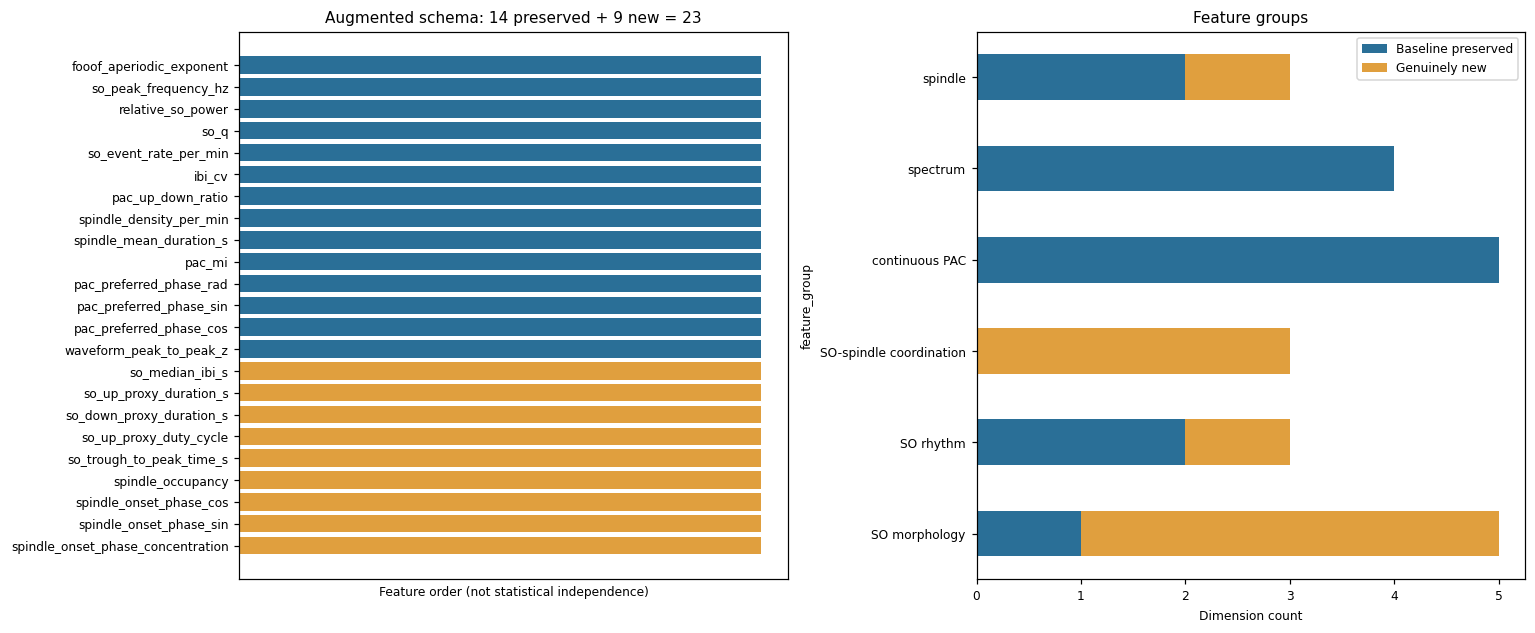

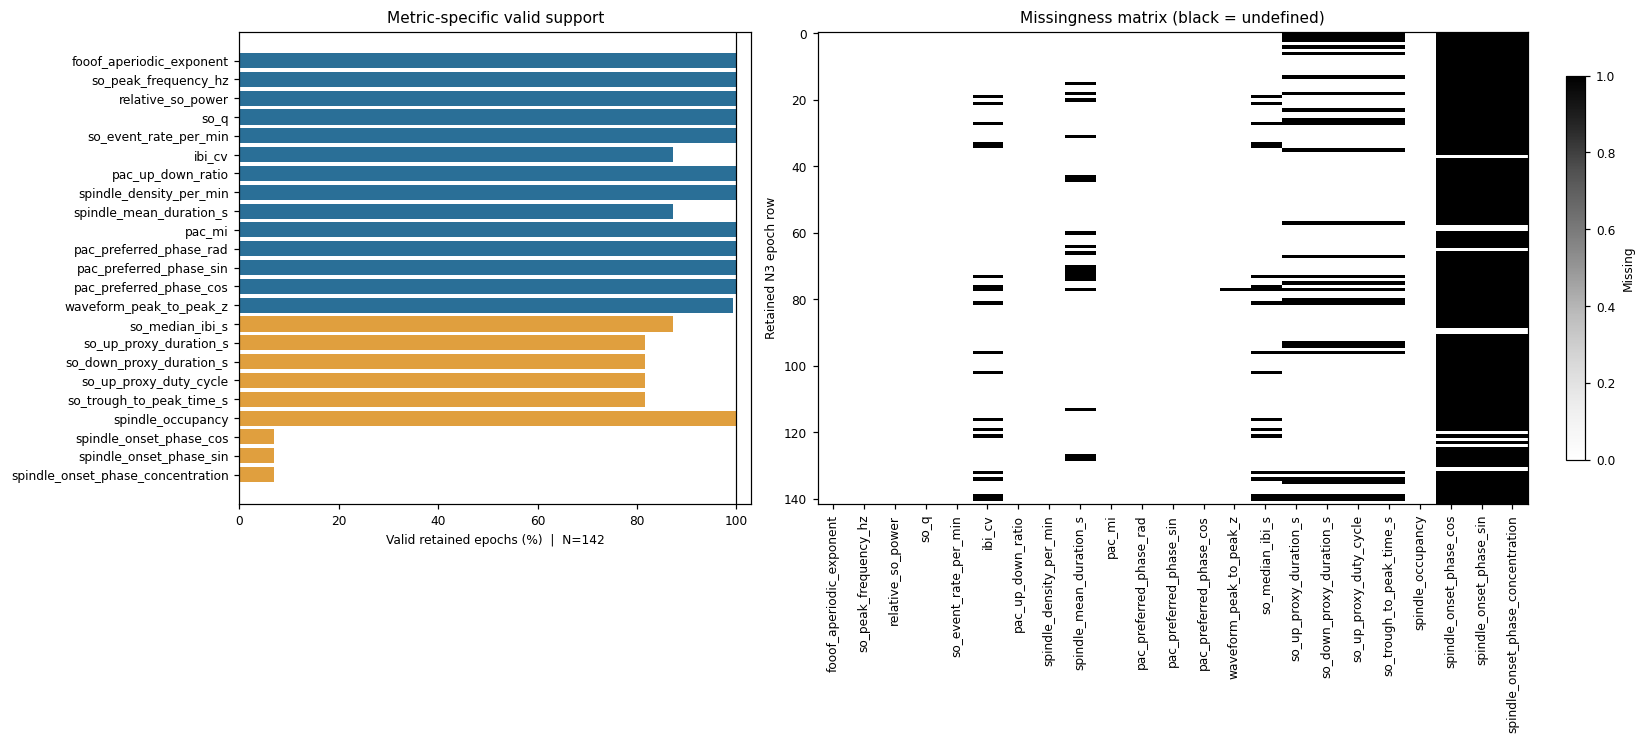

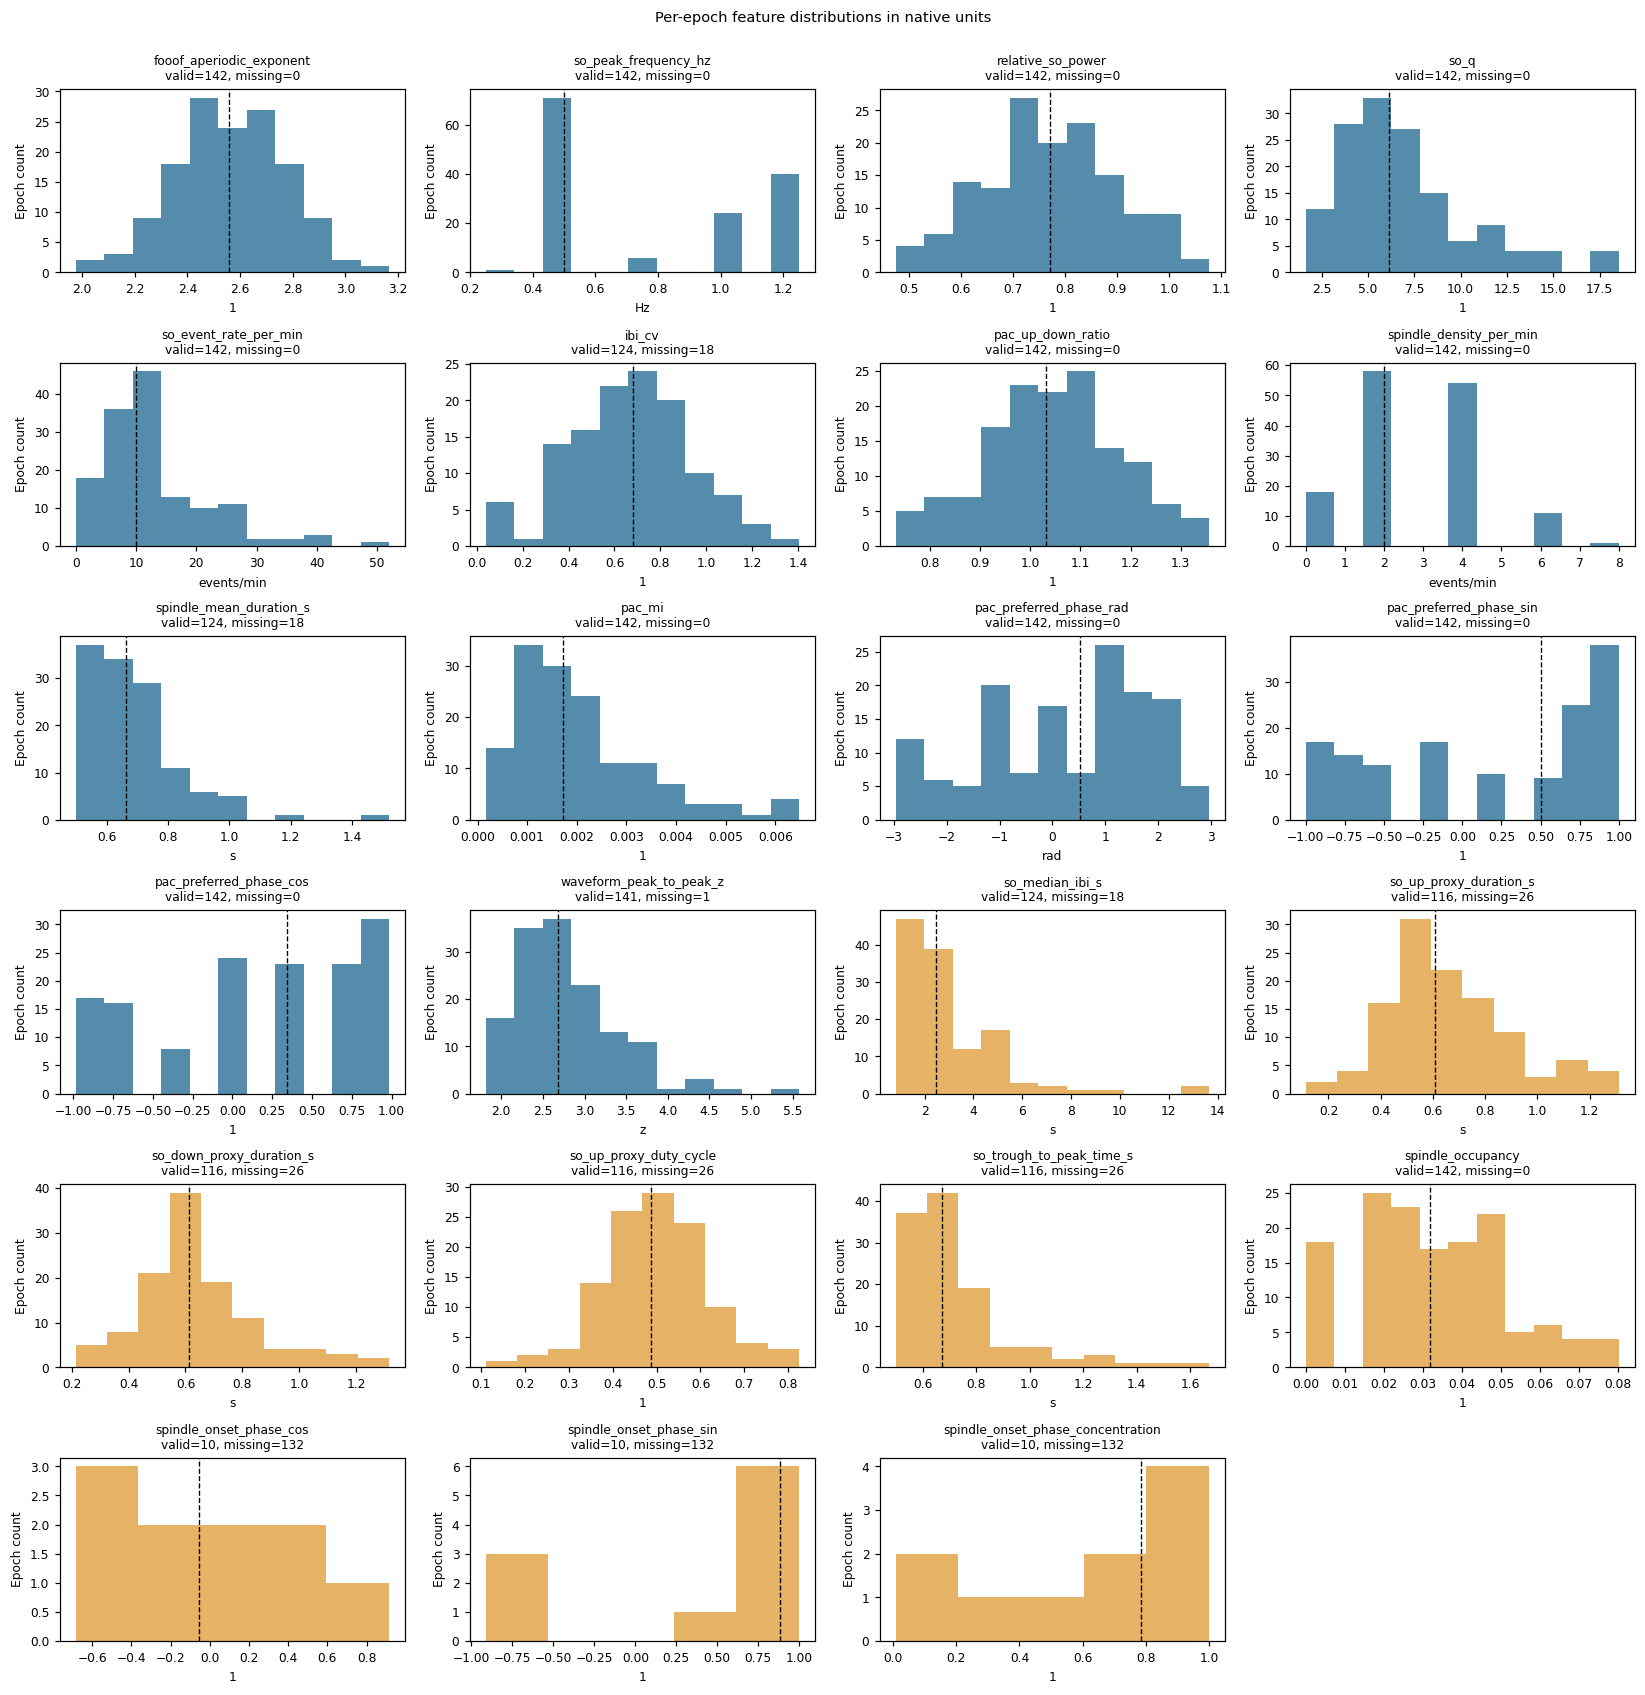

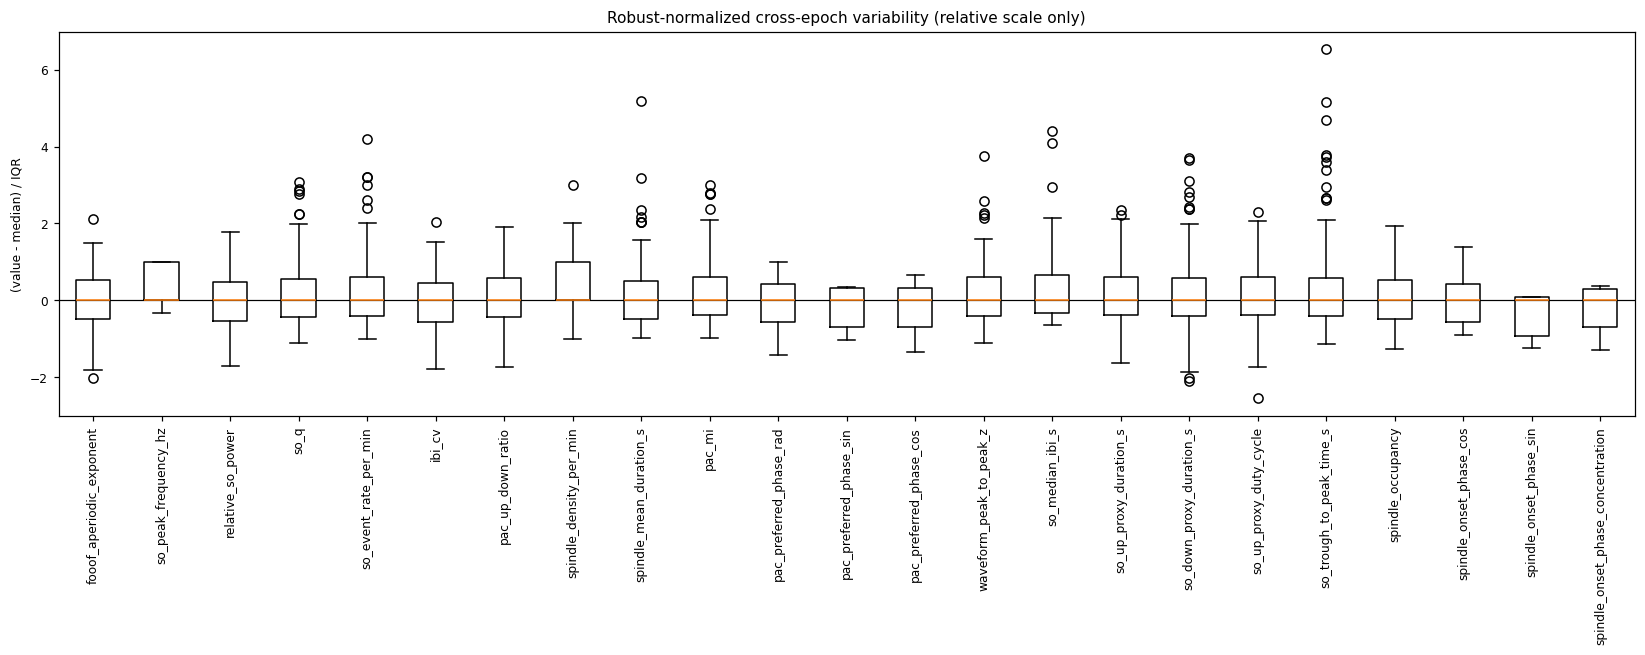

,feature_name,valid_N,missing_N,minimum,median,IQR,maximum,near_constant
0,fooof_aperiodic_exponent,142,0,1.976249,2.559156,0.287560,3.166245,False
1,so_peak_frequency_hz,142,0,0.250000,0.500000,0.750000,1.250000,False
2,relative_so_power,142,0,0.473956,0.769972,0.172399,1.076586,False
3,so_q,142,0,1.630779,6.125524,4.044156,18.544300,False
4,so_event_rate_per_min,142,0,0.000000,10.000000,10.000000,52.000000,False
5,ibi_cv,124,18,0.039049,0.679044,0.356072,1.404788,False
6,pac_up_down_ratio,142,0,0.732335,1.032362,0.171096,1.356201,False
7,spindle_density_per_min,142,0,0.000000,2.000000,2.000000,8.000000,False
8,spindle_mean_duration_s,124,18,0.500000,0.662500,0.165417,1.520000,False
9,pac_mi,142,0,0.000167,0.001725,0.001583,0.006474,False


In [9]:
BASELINE_COLOR = "#2A6F97"
NEW_COLOR = "#E09F3E"
WARNING_COLOR = "#C14953"

def save_figure(fig: plt.Figure, stem: str) -> None:
    fig.savefig(FIGURE_DIR / f"{stem}.png", dpi=180, bbox_inches="tight")
    fig.savefig(FIGURE_DIR / f"{stem}.pdf", bbox_inches="tight")

plt.rcParams.update(
    {
        "font.family": "DejaVu Sans",
        "font.size": 8,
        "axes.titlesize": 10,
        "axes.labelsize": 8,
        "figure.dpi": 110,
    }
)

group_table = (
    scheme_b_schema.groupby(["baseline_or_new", "feature_group"])
    .size()
    .rename("dimension_count")
    .reset_index()
)
fig, axes = plt.subplots(1, 2, figsize=(14, 5.8))
colors = [
    BASELINE_COLOR if value == "Baseline preserved" else NEW_COLOR
    for value in scheme_b_schema["baseline_or_new"]
]
axes[0].barh(
    np.arange(len(scheme_b_schema)),
    np.ones(len(scheme_b_schema)),
    color=colors,
)
axes[0].set_yticks(np.arange(len(scheme_b_schema)), scheme_b_schema["feature_name"])
axes[0].invert_yaxis()
axes[0].set_xticks([])
axes[0].set_title(
    f"Augmented schema: {actual_baseline_dimension} preserved + "
    f"{len(genuinely_new_feature_names)} new = {len(final_augmented_feature_names)}"
)
axes[0].set_xlabel("Feature order (not statistical independence)")
pivot_groups = group_table.pivot(
    index="feature_group", columns="baseline_or_new", values="dimension_count"
).fillna(0)
pivot_groups.plot.barh(
    stacked=True,
    color={"Baseline preserved": BASELINE_COLOR, "Genuinely new": NEW_COLOR},
    ax=axes[1],
)
axes[1].set_xlabel("Dimension count")
axes[1].set_title("Feature groups")
axes[1].legend(title="")
fig.tight_layout()
save_figure(fig, "01_dimension_overview")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(15, 6.8), gridspec_kw={"width_ratios": [1, 1.5]})
support_plot = support_summary.set_index("feature_name").loc[final_augmented_feature_names]
axes[0].barh(
    np.arange(len(support_plot)),
    support_plot["valid_epoch_percentage"],
    color=colors,
)
axes[0].set_yticks(np.arange(len(support_plot)), support_plot.index)
axes[0].invert_yaxis()
axes[0].axvline(100, color="black", linewidth=0.8)
axes[0].set_xlim(0, 103)
axes[0].set_xlabel(f"Valid retained epochs (%)  |  N={retained_count}")
axes[0].set_title("Metric-specific valid support")
missing = ~np.isfinite(X_augmented)
image = axes[1].imshow(missing, aspect="auto", interpolation="nearest", cmap="Greys")
axes[1].set_xticks(np.arange(len(final_augmented_feature_names)))
axes[1].set_xticklabels(final_augmented_feature_names, rotation=90)
axes[1].set_ylabel("Retained N3 epoch row")
axes[1].set_title("Missingness matrix (black = undefined)")
fig.colorbar(image, ax=axes[1], fraction=0.025, label="Missing")
fig.tight_layout()
save_figure(fig, "02_support_and_missingness")
plt.show()

n_features = len(final_augmented_feature_names)
ncols = 4
nrows = int(np.ceil(n_features / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 2.55 * nrows))
units = scheme_b_schema.set_index("feature_name")["unit"]
distribution_rows = []
robust_columns = {}
for axis, name in zip(axes.flat, final_augmented_feature_names):
    values = augmented_per_epoch[name].to_numpy(float)
    finite = values[np.isfinite(values)]
    q1, median, q3 = (
        np.quantile(finite, [0.25, 0.5, 0.75]) if len(finite) else (np.nan, np.nan, np.nan)
    )
    iqr = q3 - q1
    near_constant = bool(np.isfinite(iqr) and iqr <= 1e-12)
    robust = (
        (values - median) / iqr
        if np.isfinite(iqr) and iqr > 0
        else np.full_like(values, np.nan)
    )
    robust_columns[name] = robust
    distribution_rows.append(
        {
            "feature_name": name,
            "valid_N": len(finite),
            "missing_N": int(np.isnan(values).sum()),
            "minimum": float(np.min(finite)) if len(finite) else np.nan,
            "median": float(median),
            "IQR": float(iqr),
            "maximum": float(np.max(finite)) if len(finite) else np.nan,
            "near_constant": near_constant,
        }
    )
    if len(finite):
        axis.hist(finite, bins=min(18, max(5, int(np.sqrt(len(finite))))), color=BASELINE_COLOR if name in baseline_feature_names else NEW_COLOR, alpha=0.8)
        axis.axvline(median, color="black", linestyle="--", linewidth=0.9)
    else:
        axis.text(0.5, 0.5, "No finite support", ha="center", va="center")
    axis.set_title(f"{name}\nvalid={len(finite)}, missing={np.isnan(values).sum()}", fontsize=8)
    axis.set_xlabel(str(units[name]))
    axis.set_ylabel("Epoch count")
for axis in axes.flat[n_features:]:
    axis.axis("off")
fig.suptitle("Per-epoch feature distributions in native units", y=1.002)
fig.tight_layout()
save_figure(fig, "03_feature_distributions")
plt.show()

distribution_summary = pd.DataFrame(distribution_rows)
robust_frame = pd.DataFrame(robust_columns, index=retained_ids)
fig, ax = plt.subplots(figsize=(15, 6))
ax.boxplot(
    [robust_frame[name].dropna().to_numpy() for name in final_augmented_feature_names],
    tick_labels=final_augmented_feature_names,
    showfliers=True,
)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticklabels(final_augmented_feature_names, rotation=90)
ax.set_ylabel("(value - median) / IQR")
ax.set_title("Robust-normalized cross-epoch variability (relative scale only)")
fig.tight_layout()
save_figure(fig, "04_robust_variability")
plt.show()
display(distribution_summary)

## 10. Redundancy, dependency, and valid-pair counts

Spearman correlation 对 monotonic redundancy 敏感，但普通 linear/rank correlation
不能完整描述 circular association。`sin(phase)` 与 `cos(phase)` 共同编码一个
direction，raw angle、sin、cos 不能被当成三份独立证据；concentration 接近 0
表示 onset phases 分散，接近 1 表示集中。

本节显式核对：

$$
\mathrm{SO\ rate}\approx\frac{60}{\mathrm{median\ IBI}},
\quad
D_{\mathrm{UP}}=
\frac{T_{\mathrm{UP}}}
{T_{\mathrm{UP}}+T_{\mathrm{DOWN}}},
\quad
\mathrm{spindle\ occupancy}\approx
\frac{
\mathrm{spindle\ density}\times
\mathrm{mean\ duration}
}{60}.
$$

最后一个式子中的 `/60` 来自 `density` 的 events/min 与 `duration` 的 seconds
之间的单位换算。实际 aggregation 若是 “median of per-cycle ratios”，它不必严格
等于 “ratio of per-epoch medians”；这会被量化为 near-deterministic，而不是被
强行判定为 exact。

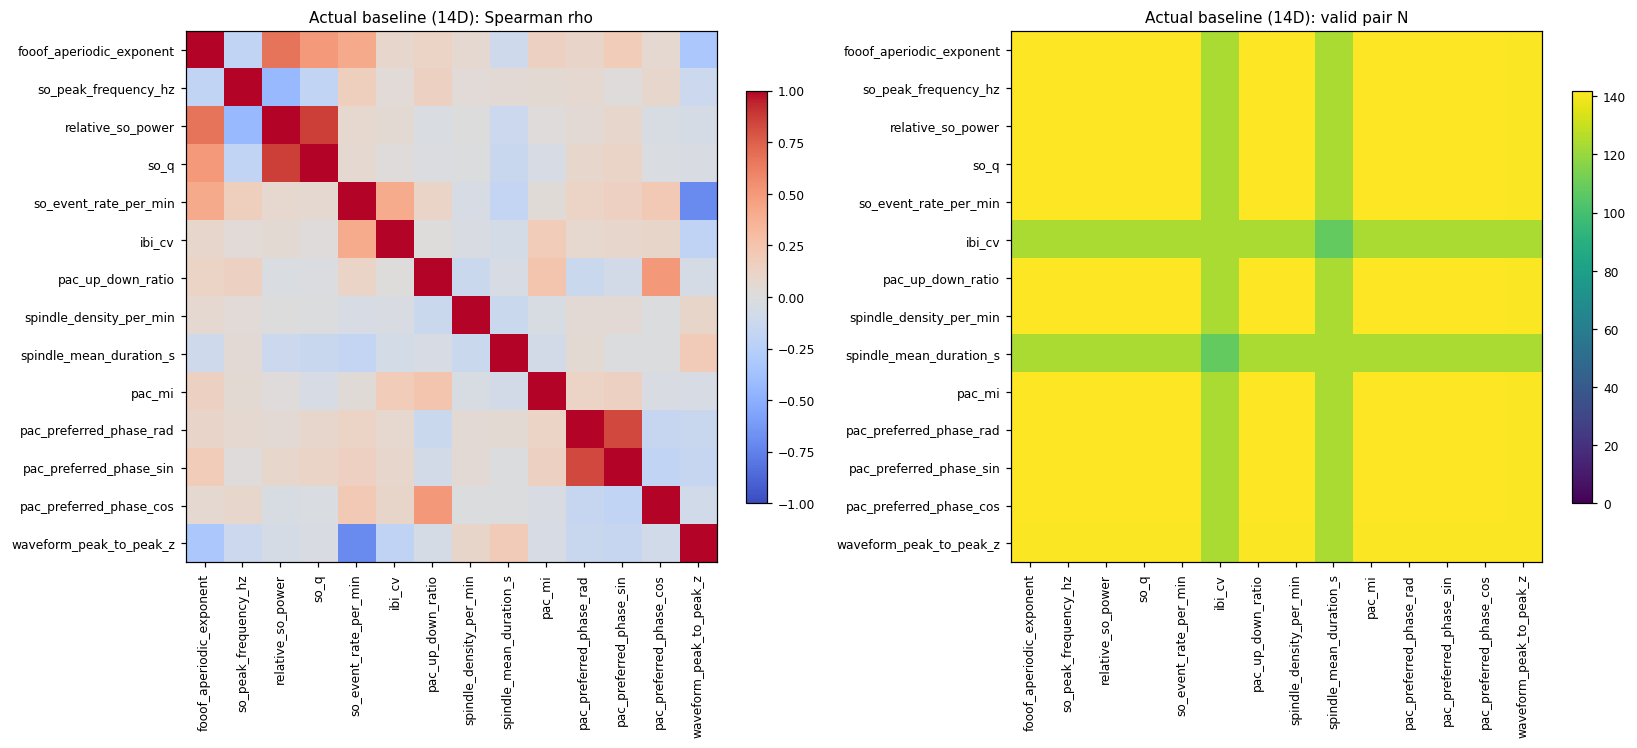

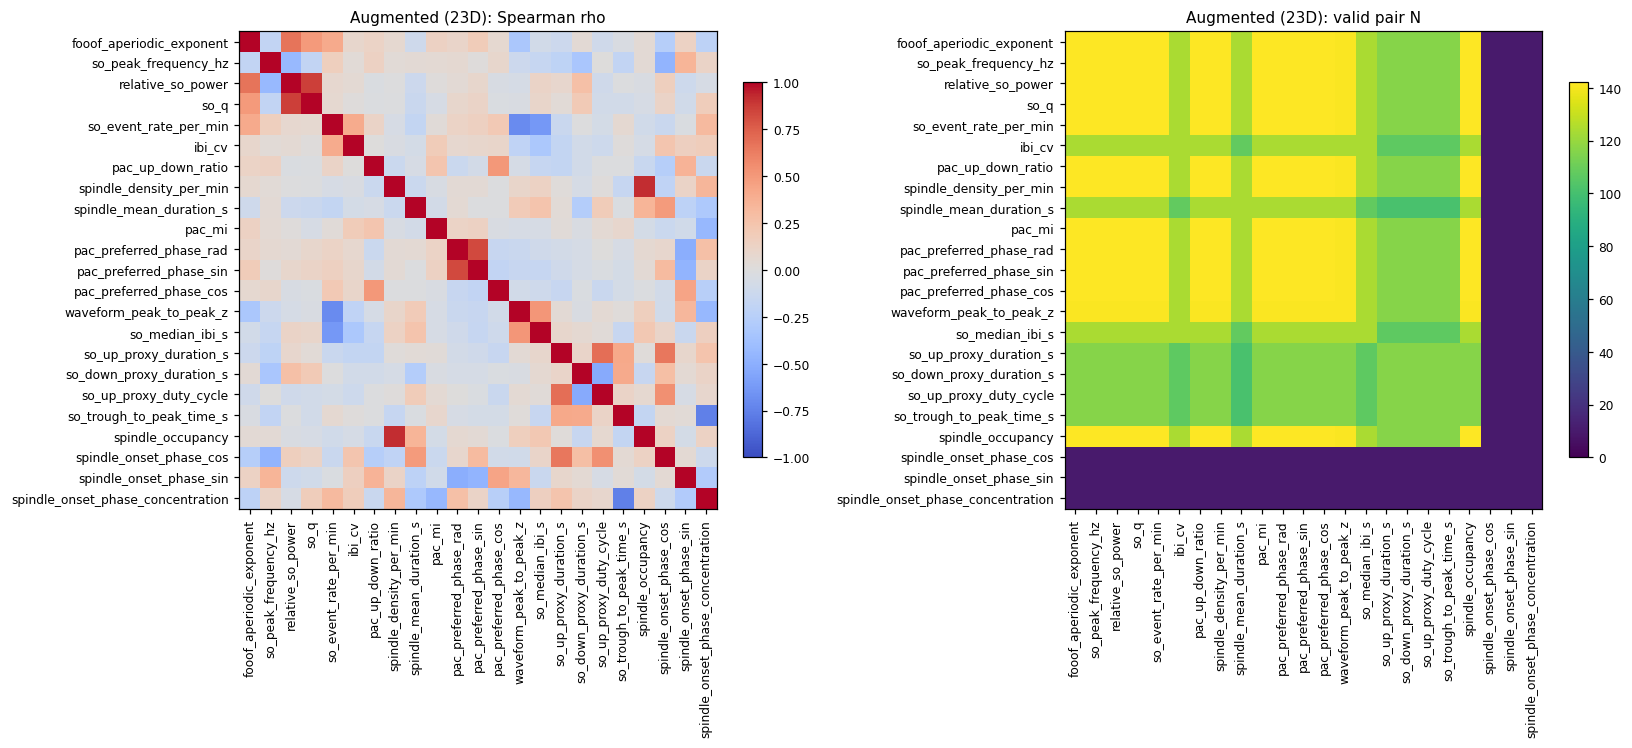

Actual Baseline high-correlation pairs:


,note
0,No Baseline |rho| >= 0.90 pairs with sufficien...


Augmented high-correlation pairs:


,Scheme,Feature A,Feature B,Spearman rho,Valid pair N,Relationship interpretation
0,Augmented,spindle_density_per_min,spindle_occupancy,0.916916,142,high monotonic redundancy; do not auto-delete


,relationship,valid_pair_N,spearman_rho,median_abs_difference,max_abs_difference,interpretation
0,SO rate vs 60/median IBI,124,0.632218,11.431842,6.361963e+01,deterministic only if event definition and agg...
1,UP duty vs ratio of per-epoch proxy medians,116,0.955507,0.007435,9.704016e-02,deterministic only if event definition and agg...
2,spindle occupancy vs density*duration/60,124,0.999984,0.000000,1.387779e-17,deterministic only if event definition and agg...


Exploratory complete-case effective rank=10; complete rows=10. No imputation was used.


In [10]:
def spearman_and_pair_counts(frame: pd.DataFrame):
    corr = frame.corr(method="spearman", min_periods=3)
    valid = frame.notna().astype(int)
    pair_count = valid.T @ valid
    return corr, pair_count

baseline_corr, baseline_pairs = spearman_and_pair_counts(baseline_per_epoch)
augmented_corr, augmented_pairs = spearman_and_pair_counts(augmented_per_epoch)

def correlation_figure(corr, pair_counts, names, stem, title):
    fig, axes = plt.subplots(1, 2, figsize=(15, 6.6))
    im0 = axes[0].imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
    axes[0].set_xticks(np.arange(len(names)), names, rotation=90)
    axes[0].set_yticks(np.arange(len(names)), names)
    axes[0].set_title(f"{title}: Spearman rho")
    fig.colorbar(im0, ax=axes[0], fraction=0.035)
    im1 = axes[1].imshow(pair_counts, vmin=0, vmax=retained_count, cmap="viridis")
    axes[1].set_xticks(np.arange(len(names)), names, rotation=90)
    axes[1].set_yticks(np.arange(len(names)), names)
    axes[1].set_title(f"{title}: valid pair N")
    fig.colorbar(im1, ax=axes[1], fraction=0.035)
    fig.tight_layout()
    save_figure(fig, stem)
    plt.show()

correlation_figure(
    baseline_corr,
    baseline_pairs,
    baseline_feature_names,
    "05_baseline_correlation_and_pair_count",
    f"Actual baseline ({actual_baseline_dimension}D)",
)
correlation_figure(
    augmented_corr,
    augmented_pairs,
    final_augmented_feature_names,
    "06_augmented_correlation_and_pair_count",
    f"Augmented ({len(final_augmented_feature_names)}D)",
)

def build_high_correlation_pairs(
    correlation: pd.DataFrame,
    pair_counts: pd.DataFrame,
    feature_names: list[str],
    scheme_name: str,
) -> pd.DataFrame:
    rows = []
    for i, left in enumerate(feature_names):
        for j in range(i + 1, len(feature_names)):
            right = feature_names[j]
            rho = float(correlation.loc[left, right])
            pair_n = int(pair_counts.loc[left, right])
            if np.isfinite(rho) and abs(rho) >= 0.90:
                interpretation = "high monotonic redundancy; do not auto-delete"
                if {left, right} == {
                    "spindle_onset_phase_cos",
                    "spindle_onset_phase_sin",
                }:
                    interpretation = (
                        "joint circular coordinates; linear rho is incomplete"
                    )
                rows.append(
                    {
                        "Scheme": scheme_name,
                        "Feature A": left,
                        "Feature B": right,
                        "Spearman rho": rho,
                        "Valid pair N": pair_n,
                        "Relationship interpretation": interpretation,
                    }
                )
    return pd.DataFrame(
        rows,
        columns=[
            "Scheme",
            "Feature A",
            "Feature B",
            "Spearman rho",
            "Valid pair N",
            "Relationship interpretation",
        ],
    )

baseline_high_correlation_pairs = build_high_correlation_pairs(
    baseline_corr,
    baseline_pairs,
    baseline_feature_names,
    "Actual Baseline",
)
augmented_high_correlation_pairs = build_high_correlation_pairs(
    augmented_corr,
    augmented_pairs,
    final_augmented_feature_names,
    "Augmented",
)

dependency_rows = []
dependency_specs = [
    (
        "SO rate vs 60/median IBI",
        augmented_per_epoch["so_event_rate_per_min"],
        60.0 / augmented_per_epoch["so_median_ibi_s"],
    ),
    (
        "UP duty vs ratio of per-epoch proxy medians",
        augmented_per_epoch["so_up_proxy_duty_cycle"],
        augmented_per_epoch["so_up_proxy_duration_s"]
        / (
            augmented_per_epoch["so_up_proxy_duration_s"]
            + augmented_per_epoch["so_down_proxy_duration_s"]
        ),
    ),
    (
        "spindle occupancy vs density*duration/60",
        augmented_per_epoch["spindle_occupancy"],
        augmented_per_epoch["spindle_density_per_min"]
        * augmented_per_epoch["spindle_mean_duration_s"]
        / 60.0,
    ),
]
for label, observed, derived in dependency_specs:
    mask = np.isfinite(observed) & np.isfinite(derived)
    dependency_rows.append(
        {
            "relationship": label,
            "valid_pair_N": int(mask.sum()),
            "spearman_rho": float(pd.Series(observed[mask]).corr(pd.Series(derived[mask]), method="spearman")) if mask.sum() >= 3 else np.nan,
            "median_abs_difference": float(np.median(np.abs(observed[mask] - derived[mask]))) if mask.any() else np.nan,
            "max_abs_difference": float(np.max(np.abs(observed[mask] - derived[mask]))) if mask.any() else np.nan,
            "interpretation": "deterministic only if event definition and aggregation commute; otherwise near-deterministic",
        }
    )
dependency_audit = pd.DataFrame(dependency_rows)

complete = augmented_per_epoch.dropna(axis=0, how="any")
if len(complete) >= 3:
    med = complete.median()
    iqr = complete.quantile(0.75) - complete.quantile(0.25)
    variable = iqr > 1e-12
    scaled = (complete.loc[:, variable] - med[variable]) / iqr[variable]
    singular_values = np.linalg.svd(scaled.to_numpy(float), compute_uv=False)
    effective_rank = int(np.sum(singular_values > singular_values.max() * 1e-10))
else:
    effective_rank = np.nan

print("Actual Baseline high-correlation pairs:")
display(
    baseline_high_correlation_pairs
    if len(baseline_high_correlation_pairs)
    else pd.DataFrame({"note": ["No Baseline |rho| >= 0.90 pairs with sufficient support"]})
)
print("Augmented high-correlation pairs:")
display(
    augmented_high_correlation_pairs
    if len(augmented_high_correlation_pairs)
    else pd.DataFrame({"note": ["No Augmented |rho| >= 0.90 pairs with sufficient support"]})
)
display(dependency_audit)
print(f"Exploratory complete-case effective rank={effective_rank}; complete rows={len(complete)}. No imputation was used.")

## 11. SNPE readiness and held-out evidence

若原 `held_out_ppc_candidate` 被纳入 Augmented input，它不能继续作为同一实验的
held-out evidence。未来需要保留 waveform-level diagnostics、未纳入 inference
的 auxiliary PAC、独立 epochs 或其他独立 observations。Readiness 还要求
simulator 产生与 EEG 完全同定义、同单位、同 validity semantics 的 fixed-column
extractor；当前尚未建立该 shared contract。

In [11]:
missing_baseline = int(np.isnan(x_o_baseline).sum())
missing_augmented = int(np.isnan(x_o_augmented).sum())
minimum_baseline_support = int(
    support_summary.query("feature_name in @baseline_feature_names")["valid_epoch_count"].min()
)
minimum_augmented_support = int(support_summary["valid_epoch_count"].min())
baseline_strong_pairs = int(len(baseline_high_correlation_pairs))
augmented_strong_pairs = int(len(augmented_high_correlation_pairs))
derivative_count = 2
readiness = pd.DataFrame(
    [
        ["Dimension", actual_baseline_dimension, len(final_augmented_feature_names), "Requested Baseline-18D is not present in executable code"],
        ["Fully finite", missing_baseline == 0, missing_augmented == 0, "Record vectors only; per-epoch missingness remains metric-specific"],
        ["Minimum feature support", minimum_baseline_support, minimum_augmented_support, f"of {retained_count} retained epochs"],
        ["Event-dependent dimensions", 10, 19, "Counts include continuous/event-conditioned timing fields"],
        ["Missing dimensions", missing_baseline, missing_augmented, "NaN is never filled with zero"],
        ["Strong redundancy pairs", baseline_strong_pairs, augmented_strong_pairs, "Each scheme is counted only within its own feature set; threshold |Spearman rho| >= 0.90"],
        ["Deterministic derivatives", 0, derivative_count, "Duty cycle and occupancy require dependency audit"],
        ["Effective rank", "not frozen", effective_rank, "Exploratory complete-case rank only; no imputation"],
        ["Same extractor applicable to simulations", False, False, "Observation-side only; simulator mapping not established"],
        ["Scaling frozen", False, False, "Recommendations are not a fitted scaler"],
        ["Aggregation frozen", "existing observation aggregate", False, "Augmented candidate aggregation requires freezing"],
        ["Validity handling frozen", False, False, "Missingness policy for SNPE is unresolved"],
        ["Held-out summaries remaining", True, True, "Must exclude any summary used as input from held-out evidence"],
        ["Ready for pilot SNPE", False, False, "Blocked by baseline dimension mismatch and missing shared simulator contract"],
    ],
    columns=["Criterion", "Baseline-18D requested / actual", "Augmented", "Interpretation"],
)
display(readiness)

,Criterion,Baseline-18D requested / actual,Augmented,Interpretation
0,Dimension,14,23,Requested Baseline-18D is not present in execu...
1,Fully finite,True,True,Record vectors only; per-epoch missingness rem...
2,Minimum feature support,124,10,of 142 retained epochs
3,Event-dependent dimensions,10,19,Counts include continuous/event-conditioned ti...
4,Missing dimensions,0,0,NaN is never filled with zero
5,Strong redundancy pairs,0,1,Each scheme is counted only within its own fea...
6,Deterministic derivatives,0,2,Duty cycle and occupancy require dependency audit
7,Effective rank,not frozen,10,Exploratory complete-case rank only; no imputa...
8,Same extractor applicable to simulations,False,False,Observation-side only; simulator mapping not e...
9,Scaling frozen,False,False,Recommendations are not a fitted scaler


## 12. Artifact export and reload in `neurolib`

文件名遵循任务要求，但 JSON 内明确记录实际 executable dimension 和 blocker。
NPZ 仅含 numeric/Unicode arrays，不含 object dtype，因此 reload 不需要
`allow_pickle=True`。CSV、JSON、NPZ 与 notebook 中的 feature order 必须一致。

In [12]:
SCHEMA_VERSION = "observation-schema-comparison-v0.1-audit"
CREATION_TIME = datetime.now(timezone.utc).isoformat()

def json_safe(value):
    if isinstance(value, dict):
        return {str(key): json_safe(item) for key, item in value.items()}
    if isinstance(value, (list, tuple)):
        return [json_safe(item) for item in value]
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return None if not np.isfinite(value) else float(value)
    if isinstance(value, (np.bool_,)):
        return bool(value)
    if pd.isna(value):
        return None
    return value

common_metadata = {
    "schema_version": SCHEMA_VERSION,
    "creation_date_utc": CREATION_TIME,
    "subject_id": bundle.subject_id,
    "channel": bundle.channel,
    "fs_hz": bundle.fs_hz,
    "epoch_duration_s": bundle.epoch_duration_s,
    "source_notebooks": [str(path.relative_to(REPO_ROOT)).replace("\\", "/") for path in SOURCE_NOTEBOOKS],
    "source_implementation": [
        "S4_sbi/src/sleep_sbi/observation.py",
        "S4_sbi/src/sleep_sbi/pyloric_inspired_observation.py",
    ],
    "config_files": [
        str(OBS_CONFIG_PATH.relative_to(REPO_ROOT)).replace("\\", "/"),
        str(LATEST_CONFIG_PATH.relative_to(REPO_ROOT)).replace("\\", "/"),
    ],
    "retained_epoch_count": retained_count,
    "requested_baseline_dimension": REQUESTED_BASELINE_DIMENSION,
    "requested_baseline18_available": requested_baseline18_available,
    "reviewer_note": (
        "Documentation-code mismatch: 01_observation executable scalar "
        f"schema has {actual_baseline_dimension} fields, not 18."
    ),
}
baseline_json = {
    **common_metadata,
    "schema_name": "Baseline-18D requested; executable Baseline-14 observed",
    "actual_dimension": actual_baseline_dimension,
    "feature_order": baseline_feature_names,
    "features": json_safe(scheme_a_schema.to_dict(orient="records")),
    "aggregation_status": "existing observation aggregate; future SNPE contract not frozen",
    "freeze_status": "blocked",
}
augmented_json = {
    **common_metadata,
    "schema_name": "Augmented = executable baseline + genuinely new EEG dimensions",
    "actual_dimension": len(final_augmented_feature_names),
    "feature_order": final_augmented_feature_names,
    "baseline_prefix_dimension": actual_baseline_dimension,
    "genuinely_new_feature_order": genuinely_new_feature_names,
    "features": json_safe(scheme_b_schema.to_dict(orient="records")),
    "aggregation_status": "provisional - aggregation not yet frozen for SNPE",
    "freeze_status": "candidate",
}

baseline_json_path = RESULT_DIR / "observation_schema_baseline18.json"
augmented_json_path = RESULT_DIR / "observation_schema_augmented.json"
crosswalk_path = RESULT_DIR / "observation_feature_crosswalk.csv"
support_path = RESULT_DIR / "observation_support_summary.csv"
npz_path = RESULT_DIR / "real_observation_vectors.npz"

baseline_json_path.write_text(json.dumps(baseline_json, indent=2, ensure_ascii=True), encoding="utf-8")
augmented_json_path.write_text(json.dumps(augmented_json, indent=2, ensure_ascii=True), encoding="utf-8")
crosswalk.to_csv(crosswalk_path, index=False)
support_summary.to_csv(support_path, index=False)
np.savez_compressed(
    npz_path,
    x_o_baseline=x_o_baseline.astype(np.float64),
    x_o_augmented=x_o_augmented.astype(np.float64),
    baseline_feature_names=np.asarray(baseline_feature_names, dtype=str),
    augmented_feature_names=np.asarray(final_augmented_feature_names, dtype=str),
    schema_version=np.asarray(SCHEMA_VERSION, dtype=str),
    support_metadata=np.asarray(
        json.dumps(json_safe(support_summary.to_dict(orient="records")), ensure_ascii=True),
        dtype=str,
    ),
    aggregation_status=np.asarray(
        "provisional - augmented aggregation not frozen; baseline-18 contract unavailable",
        dtype=str,
    ),
    baseline_finite_mask=np.isfinite(x_o_baseline),
    augmented_finite_mask=np.isfinite(x_o_augmented),
)

reloaded_baseline = json.loads(baseline_json_path.read_text(encoding="utf-8"))
reloaded_augmented = json.loads(augmented_json_path.read_text(encoding="utf-8"))
reloaded_crosswalk = pd.read_csv(crosswalk_path)
reloaded_support = pd.read_csv(support_path)
with np.load(npz_path, allow_pickle=False) as reloaded_npz:
    npz_files = list(reloaded_npz.files)
    npz_dtypes = {name: str(reloaded_npz[name].dtype) for name in npz_files}
    assert not any(reloaded_npz[name].dtype.kind == "O" for name in npz_files)
    assert reloaded_npz["baseline_feature_names"].tolist() == baseline_feature_names
    assert reloaded_npz["augmented_feature_names"].tolist() == final_augmented_feature_names
    assert np.allclose(reloaded_npz["x_o_baseline"], x_o_baseline, rtol=0, atol=0, equal_nan=True)
    assert np.allclose(reloaded_npz["x_o_augmented"], x_o_augmented, rtol=0, atol=0, equal_nan=True)
    assert str(reloaded_npz["schema_version"]) == SCHEMA_VERSION

assert reloaded_baseline["feature_order"] == baseline_feature_names
assert reloaded_augmented["feature_order"] == final_augmented_feature_names
assert len(reloaded_crosswalk) == len(crosswalk)
assert reloaded_support["feature_name"].tolist() == final_augmented_feature_names

artifact_report = pd.DataFrame(
    {
        "artifact": [
            baseline_json_path.name,
            augmented_json_path.name,
            crosswalk_path.name,
            support_path.name,
            npz_path.name,
        ],
        "relative_path": [
            str(path.relative_to(REPO_ROOT)).replace("\\", "/")
            for path in [baseline_json_path, augmented_json_path, crosswalk_path, support_path, npz_path]
        ],
        "size_bytes": [
            path.stat().st_size
            for path in [baseline_json_path, augmented_json_path, crosswalk_path, support_path, npz_path]
        ],
        "reload": ["pass"] * 5,
    }
)
display(artifact_report)
print("NPZ dtypes:", npz_dtypes)

,artifact,relative_path,size_bytes,reload
0,observation_schema_baseline18.json,S4_sbi/results/observation_schema_comparison/o...,17449,pass
1,observation_schema_augmented.json,S4_sbi/results/observation_schema_comparison/o...,27300,pass
2,observation_feature_crosswalk.csv,S4_sbi/results/observation_schema_comparison/o...,6230,pass
3,observation_support_summary.csv,S4_sbi/results/observation_schema_comparison/o...,4555,pass
4,real_observation_vectors.npz,S4_sbi/results/observation_schema_comparison/r...,4615,pass


NPZ dtypes: {'x_o_baseline': 'float64', 'x_o_augmented': 'float64', 'baseline_feature_names': '<U24', 'augmented_feature_names': '<U33', 'schema_version': '<U40', 'support_metadata': '<U10445', 'aggregation_status': '<U80', 'baseline_finite_mask': 'bool', 'augmented_finite_mask': 'bool'}


## 13. Final validation, immutable-source proof, and conclusions

最后检查 input notebook hashes、schema order、prefix、finite/NaN/Inf、bounded
features、artifact reload 和 figure existence。唯一预期 blocker 是 requested
Baseline-18D 与实际 14D code contract 不一致；它不会被伪装成通过。

**Scientific conclusion.** 当前可证实的方案是 Actual Baseline-14 与
Augmented-23，而不是 Baseline-18 与未知 augmented dimension。新增 9 项是：
median IBI、UP/DOWN proxy duration、duty cycle、trough-to-peak time、
spindle occupancy，以及 event-conditioned onset phase cos/sin/concentration。
Duty cycle、occupancy 和 phase coordinates 有结构性依赖；event-conditioned
phase support 最低。两套 matrices 都 fixed-column，record vectors fixed-length，
但 shared simulator extractor、scaling、aggregation、validity/missingness policy
与 held-out design 尚未冻结，因此不能进入 pilot SNPE，更不能断言哪套 posterior
更窄、更准或更具生理真实性。

In [13]:
SOURCE_HASHES_AT_END = {path.name: file_sha256(path) for path in SOURCE_NOTEBOOKS}
source_hashes_unchanged = SOURCE_HASHES_AT_END == SOURCE_HASHES_AT_START

bounded_checks = {
    "so_up_proxy_duty_cycle": (0.0, 1.0),
    "spindle_occupancy": (0.0, 1.0),
    "spindle_onset_phase_concentration": (0.0, 1.0),
}
bounded_pass = {}
for name, (lower, upper) in bounded_checks.items():
    values = augmented_per_epoch[name].to_numpy(float)
    finite = values[np.isfinite(values)]
    bounded_pass[name] = bool(((finite >= lower) & (finite <= upper)).all())

expected_figure_stems = [
    "01_dimension_overview",
    "02_support_and_missingness",
    "03_feature_distributions",
    "04_robust_variability",
    "05_baseline_correlation_and_pair_count",
    "06_augmented_correlation_and_pair_count",
]
figure_files_exist = all(
    (FIGURE_DIR / f"{stem}.{suffix}").exists()
    for stem in expected_figure_stems
    for suffix in ("png", "pdf")
)

validation = pd.DataFrame(
    [
        ["nbformat.validate", nbformat_validation_result == "PASS", nbformat_validation_result],
        ["neurolib environment", env_name == "neurolib", env_name],
        ["sys.executable complete", "neurolib" in sys.executable.lower(), sys.executable],
        ["sys.prefix complete", "neurolib" in sys.prefix.lower(), sys.prefix],
        ["kernel ID/display name", kernel_id == "python3" and kernel_display_name == "neurolib", f"{kernel_id} / {kernel_display_name}"],
        ["neurolib executable", "neurolib" in sys.executable.lower(), sys.executable],
        ["source notebook hashes unchanged", source_hashes_unchanged, json.dumps(SOURCE_HASHES_AT_END)],
        ["epoch accounting", retained_count + rejected_count == n3_count, f"{retained_count}+{rejected_count}={n3_count}"],
        ["non-N3 excluded from QC rejection", (latest.epoch_ledger.loc[~latest.epoch_ledger['is_n3'], 'global_qc_status'] == 'not_applicable_non_n3').all(), "N3-only QC"],
        ["requested Baseline-18D contract available", requested_baseline18_available, f"actual={actual_baseline_dimension}, requested=18"],
        ["actual baseline fixed-column", X_baseline.shape == (retained_count, actual_baseline_dimension), str(X_baseline.shape)],
        ["augmented fixed-column", X_augmented.shape == (retained_count, len(final_augmented_feature_names)), str(X_augmented.shape)],
        ["Constructive prefix identity", per_epoch_equality["Pass"].all(), f"X_augmented=[X_baseline, X_new]; not independent extractor regression; rtol={RTOL}, atol={ATOL}"],
        ["record prefix equality", np.allclose(x_o_augmented[:actual_baseline_dimension], x_o_baseline, rtol=RTOL, atol=ATOL, equal_nan=True), f"rtol={RTOL}, atol={ATOL}"],
        ["record vectors contain no Inf", not np.isinf(x_o_augmented).any(), f"Inf={np.isinf(x_o_augmented).sum()}"],
        ["bounded features in [0,1]", all(bounded_pass.values()), json.dumps(bounded_pass)],
        ["circular invalid masks aligned", all(np.array_equal(circular_masks[0], mask) for mask in circular_masks[1:]), str([int(mask.sum()) for mask in circular_masks])],
        ["artifacts reloaded", True, ", ".join(artifact_report["artifact"])],
        ["figures PNG/PDF exist", figure_files_exist, str(FIGURE_DIR.relative_to(REPO_ROOT))],
        ["ready for pilot SNPE", False, "blocked: requested baseline contract, shared simulator extractor, scaling/aggregation/validity not frozen"],
    ],
    columns=["validation_check", "passed", "evidence"],
)
display(validation)

critical_checks = validation.loc[
    ~validation["validation_check"].isin(
        ["requested Baseline-18D contract available", "ready for pilot SNPE"]
    )
]
assert critical_checks["passed"].all()
final_git_status_short = subprocess.run(
    ["git", "status", "--short"], cwd=REPO_ROOT, check=True,
    capture_output=True, text=True, encoding="utf-8", errors="replace"
).stdout.rstrip()
final_git_diff_stat = subprocess.run(
    ["git", "diff", "--stat"], cwd=REPO_ROOT, check=True,
    capture_output=True, text=True, encoding="utf-8", errors="replace"
).stdout.rstrip()
print("\nFinal git status --short:")
print(final_git_status_short or "(clean)")
print("\nFinal git diff --stat:")
print(final_git_diff_stat or "(no tracked diff)")
print("\nFINAL STATUS: execution and artifact validation passed.")
print("SCIENTIFIC STATUS: not ready for pilot SNPE; see the two explicit blockers above.")

,validation_check,passed,evidence
0,nbformat.validate,True,PASS
1,neurolib environment,True,neurolib
2,sys.executable complete,True,C:\Users\YUS190\AppData\Local\anaconda3\envs\n...
3,sys.prefix complete,True,C:\Users\YUS190\AppData\Local\anaconda3\envs\n...
4,kernel ID/display name,True,python3 / neurolib
5,neurolib executable,True,C:\Users\YUS190\AppData\Local\anaconda3\envs\n...
6,source notebook hashes unchanged,True,"{""01_observation.ipynb"": ""10045788079b7c65b558..."
7,epoch accounting,True,142+78=220
8,non-N3 excluded from QC rejection,True,N3-only QC
9,requested Baseline-18D contract available,False,"actual=14, requested=18"



Final git status --short:
 D S4_sbi/compute_xobs_from_eeg.py
 D S4_sbi/compute_xobs_from_eeg_v1_buggy.py
 D S4_sbi/compute_xobs_from_eeg_v2.py
 M S4_sbi/compute_xobs_from_eeg_v4.py
 M S4_sbi/notebooks/01_Pyloric_Inspired_Observation_annotated.ipynb
 D S4_sbi/plot_scan_diagnostics.py
 D S4_sbi/run_sbc_standalone.py
 D S4_sbi/scan_xobs_params.py
 D S4_sbi/x_obs.npz
 M docs/Claude_Writing/BMEiCON_STAGE1_MANUSCRIPT.docx
 M docs/Claude_Writing/BMEiCON_STAGE1_MANUSCRIPT.md
 M docs/Claude_Writing/BMEiCON_STAGE1_MANUSCRIPT.tex
 M docs/Claude_Writing/build_manuscript_docx.py
 M models/s4_personalize_fig7_v2.py
 M valid_scripts/validate_so_waveform_heldout.py
 M valid_scripts/validate_spindle_density_heldout.py
?? S4_sbi/legacy/
?? S4_sbi/notebooks/02_Observation_Schema_Comparison.ipynb
?? S4_sbi/results/
?? S4_sbi/scan_diagnostics/fig_concat_vs_mean_psd_overview.png
?? S4_sbi/scan_diagnostics/fig_concat_vs_mean_psd_so_zoom.png
?? S4_sbi/scan_diagnostics/fig_concat_vs_mean_psd_timeline.png
?? d